<a href="https://colab.research.google.com/github/Saldon1986/Simulative_ML/blob/main/Simulative_%D0%92%D0%B5%D0%B1%D0%B8%D0%BD%D0%B0%D1%80_%D0%92%D1%80%D0%B5%D0%BC%D0%B5%D0%BD%D0%BD%D1%8B%D0%B5_%D1%80%D1%8F%D0%B4%D1%8B%2C_%D0%BF%D1%80%D0%BE%D0%B3%D0%BD%D0%BE%D0%B7%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SARIMA**

**S (Seasonal)**: компонента, учитывающая сезонность ряда.

**AR (AutoRegressive)**: авторегрессионная компонента модели, которая описывает зависимость текущего значения временного ряда от предыдущих значений в этом же ряде. Параметр авторегрессии обозначается как p. Его можно интерпретировать как выражение «элемент ряда будет близок к Х, если предыдущие р элементов были близки к Х».

**I (Integrated)**: определяет количество раз, которое временной ряд должен быть дифференцирован (изменен) для того, чтобы сделать его стационарным. Параметр интеграции обозначается как d — порядок интегрирования (разностей исходного временного ряда). Можно понимать как «элемент будет близок по значению к предыдущим d элементам, если их разность минимальна».

**MA (Moving Average)**: зависимость текущего значения временного ряда от предыдущих ошибок прогноза (ошибок модели скользящего среднего). Параметр обозначается как q. Порядок скользящего среднего, который позволяет установить погрешность модели как линейную комбинацию наблюдавшихся ранее значений ошибок.

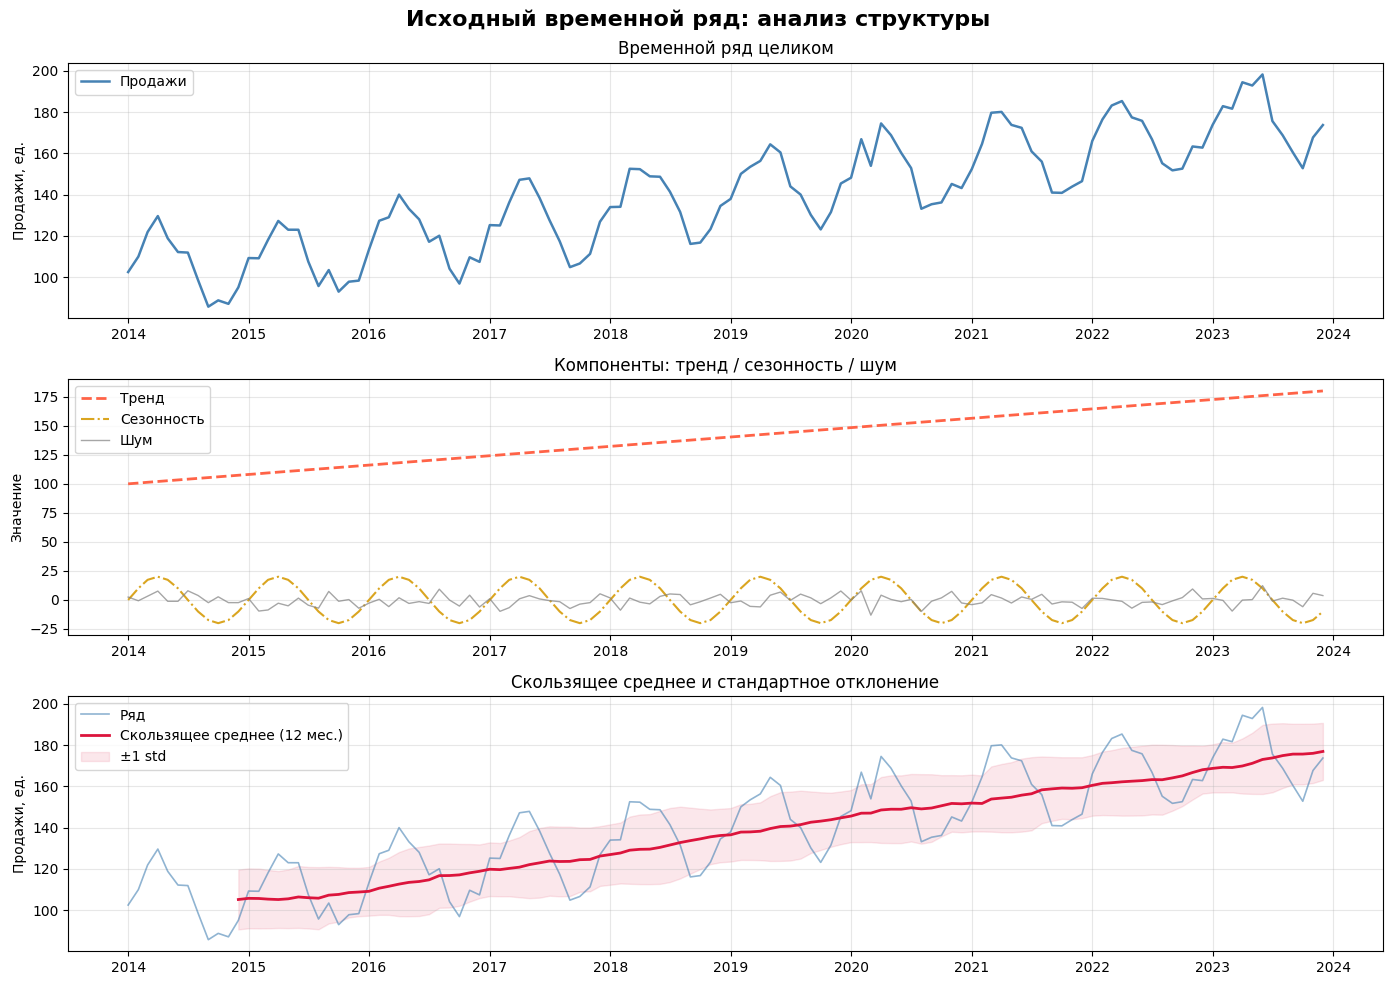

Длина ряда: 120 месяцев
Период: 2014-01-01 → 2023-12-01
Среднее: 139.6,  Std: 26.9
Мин: 85.7,  Макс: 198.3


In [ ]:
###################
# SARIMA
###################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── Воспроизводимость ──────────────────────────────────────────────────────────
np.random.seed(42)

# ── Параметры генерации ────────────────────────────────────────────────────────
N_PERIODS   = 120          # 10 лет помесячных наблюдений
SEASON_LEN  = 12           # сезонность: 12 месяцев
TEST_SIZE   = 24           # последние 2 года — тестовая выборка

# ── Генерация ряда: тренд + сезонность + шум ──────────────────────────────────
dates  = pd.date_range(start='2014-01-01', periods=N_PERIODS, freq='MS')
trend  = np.linspace(100, 180, N_PERIODS)                        # линейный рост
season = 20 * np.sin(2 * np.pi * np.arange(N_PERIODS) / SEASON_LEN)  # сезонность
noise  = np.random.normal(0, 5, N_PERIODS)                       # случайный шум

values = trend + season + noise
series = pd.Series(values, index=dates, name='Sales')

# ── Визуализация ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Исходный временной ряд: анализ структуры', fontsize=16, fontweight='bold')

# График 1: исходный ряд
ax = axes[0]
ax.plot(series, color='steelblue', linewidth=1.8, label='Продажи')
ax.set_title('Временной ряд целиком')
ax.set_ylabel('Продажи, ед.')
ax.legend()
ax.grid(alpha=0.3)

# График 2: компоненты ряда наглядно
ax = axes[1]
ax.plot(dates, trend,  color='tomato',    linewidth=2,   label='Тренд',      linestyle='--')
ax.plot(dates, season, color='goldenrod', linewidth=1.5, label='Сезонность', linestyle='-.')
ax.plot(dates, noise,  color='gray',      linewidth=1,   label='Шум',        alpha=0.7)
ax.set_title('Компоненты: тренд / сезонность / шум')
ax.set_ylabel('Значение')
ax.legend()
ax.grid(alpha=0.3)

# График 3: скользящее среднее (12 месяцев)
ax = axes[2]
rolling_mean = series.rolling(window=12).mean()
rolling_std  = series.rolling(window=12).std()
ax.plot(series,       color='steelblue', linewidth=1.2, alpha=0.6, label='Ряд')
ax.plot(rolling_mean, color='crimson',   linewidth=2,   label='Скользящее среднее (12 мес.)')
ax.fill_between(
    dates,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    color='crimson', alpha=0.1, label='±1 std'
)
ax.set_title('Скользящее среднее и стандартное отклонение')
ax.set_ylabel('Продажи, ед.')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Длина ряда: {len(series)} месяцев")
print(f"Период: {series.index[0].date()} → {series.index[-1].date()}")
print(f"Среднее: {series.mean():.1f},  Std: {series.std():.1f}")
print(f"Мин: {series.min():.1f},  Макс: {series.max():.1f}")



──────────────────────────────────────────────────
ADF-тест: исходный ряд
  Статистика : 0.8428
  p-value    : 0.9923
  Критич. 5%: -2.8892
  Вывод      : ❌ НЕ стационарен

──────────────────────────────────────────────────
ADF-тест: сезонное дифференцирование (lag=12)
  Статистика : -5.0741
  p-value    : 0.0000
  Критич. 5%: -2.8925
  Вывод      : ✅ СТАЦИОНАРЕН

──────────────────────────────────────────────────
ADF-тест: сезонное + обычное дифференцирование
  Статистика : -4.1060
  p-value    : 0.0009
  Критич. 5%: -2.8932
  Вывод      : ✅ СТАЦИОНАРЕН


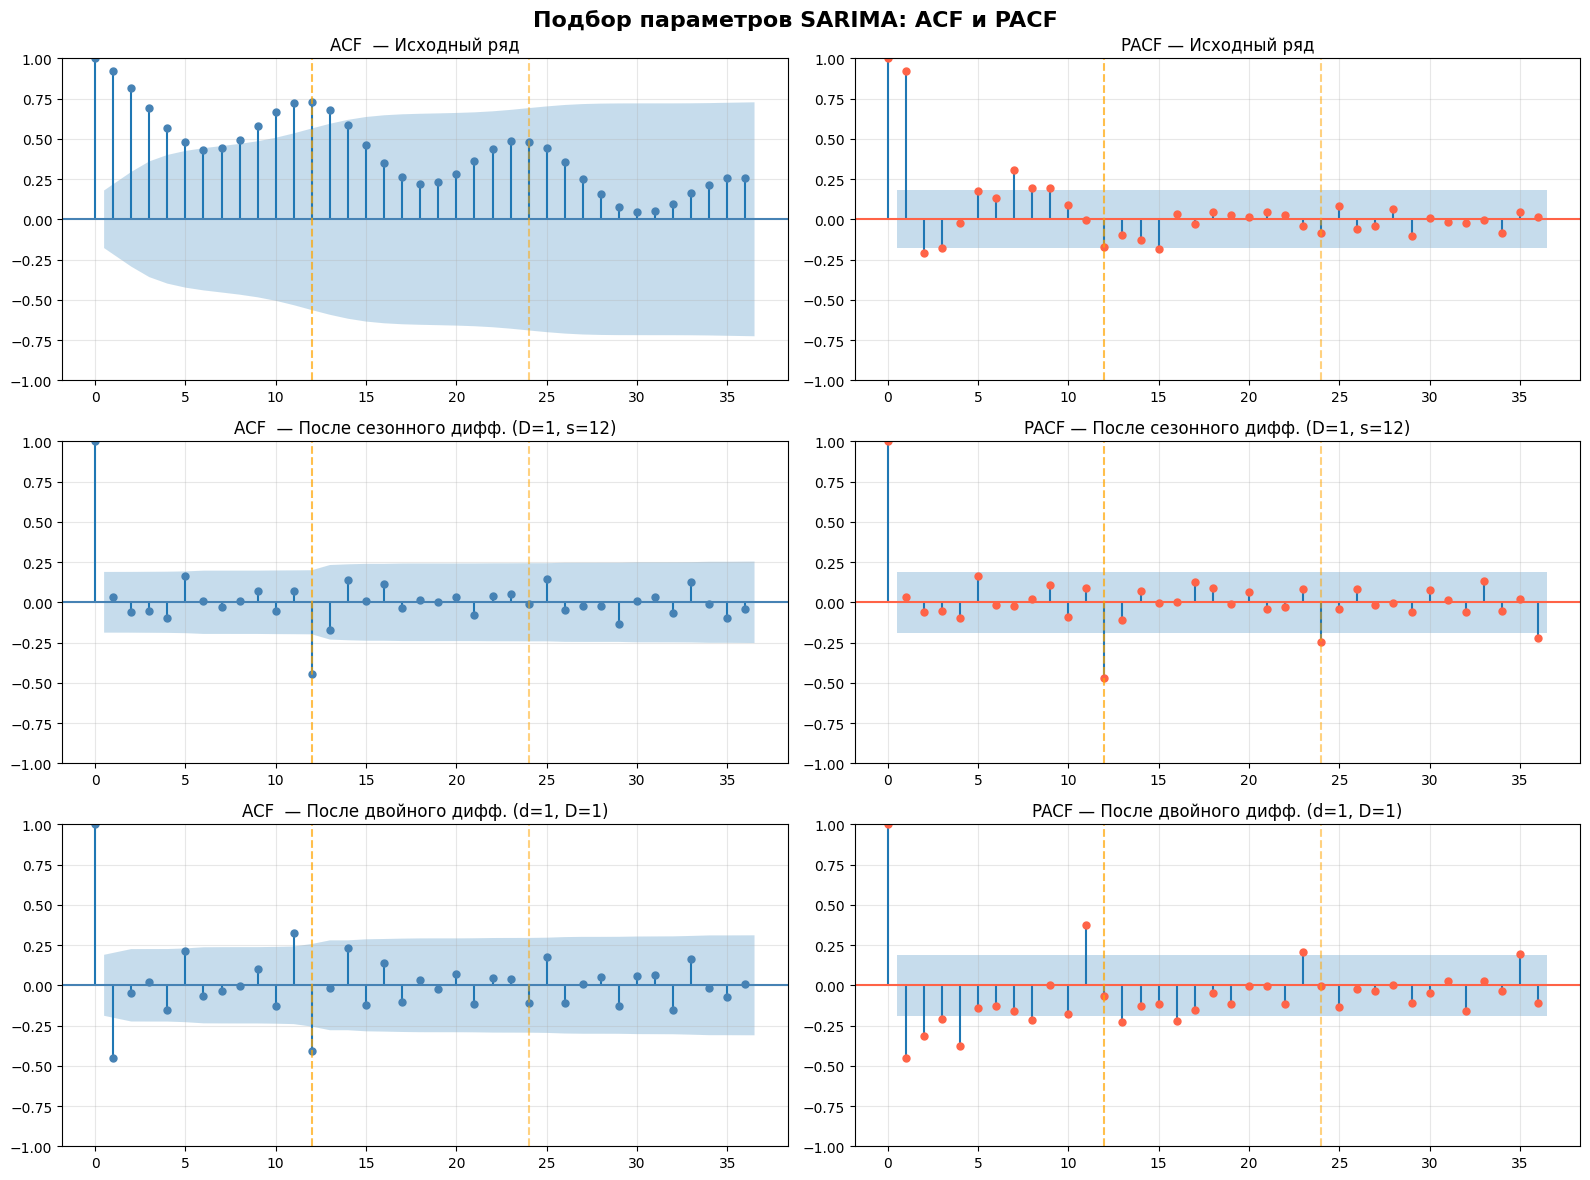


СВОДНАЯ ТАБЛИЦА ПРАВИЛ ОПРЕДЕЛЕНИЯ ПАРАМЕТРОВ:

AR(p):
  ACF: Плавное затухание
  PACF: Резкий обрыв после лага p
  Параметры: p = последний значимый лаг в PACF, q = 0

MA(q):
  ACF: Резкий обрыв после лага q
  PACF: Плавное затухание
  Параметры: p = 0, q = последний значимый лаг в ACF

ARMA(p,q):
  ACF: Экспоненциальное затухание с лага 1
  PACF: Экспоненциальное затухание с лага 1
  Параметры: Экспериментировать с небольшими значениями p и q (обычно 1-2)

🔍 Grid Search по AIC...
Параметры                                  AIC        BIC
──────────────────────────────────────────────────────────
SARIMA(0,1,0)x(0,1,0,12)                609.94     612.34  ← лучший
SARIMA(0,1,0)x(0,1,1,12)                482.85     487.35  ← лучший
SARIMA(0,1,0)x(1,1,0,12)                512.94     517.46
SARIMA(0,1,0)x(1,1,1,12)                492.44     499.19
SARIMA(0,1,1)x(0,1,0,12)                548.75     553.54
SARIMA(0,1,1)x(0,1,1,12)                430.78     437.48  ← лучший
SARIMA(0,1,1)x(1,

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ШАГ 1: Проверка стационарности (тест Дики-Фуллера)
# ══════════════════════════════════════════════════════════════════════════════

def adf_report(ts: pd.Series, label: str = '') -> bool:
    """Выводит результат ADF-теста и возвращает True если ряд стационарен."""
    result = adfuller(ts.dropna(), autolag='AIC')
    is_stationary = result[1] < 0.05
    status = '✅ СТАЦИОНАРЕН' if is_stationary else '❌ НЕ стационарен'
    print(f"\n{'─'*50}")
    print(f"ADF-тест: {label}")
    print(f"  Статистика : {result[0]:.4f}")
    print(f"  p-value    : {result[1]:.4f}")
    print(f"  Критич. 5%: {result[4]['5%']:.4f}")
    print(f"  Вывод      : {status}")
    return is_stationary

# Исходный ряд
adf_report(series, 'исходный ряд')

# Первое сезонное дифференцирование (D=1, период=12)
series_seasonal_diff = series.diff(12).dropna()
adf_report(series_seasonal_diff, 'сезонное дифференцирование (lag=12)')

# Первое обычное дифференцирование поверх сезонного
series_double_diff = series_seasonal_diff.diff(1).dropna()
adf_report(series_double_diff, 'сезонное + обычное дифференцирование')

# ══════════════════════════════════════════════════════════════════════════════
# ШАГ 2: ACF и PACF — визуальный подбор p и q
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Подбор параметров SARIMA: ACF и PACF', fontsize=16, fontweight='bold')

LAGS = 36   # смотрим на 3 сезона вперёд

plot_configs = [
    (series,              'Исходный ряд',                      axes[0, 0], axes[0, 1]),
    (series_seasonal_diff,'После сезонного дифф. (D=1, s=12)', axes[1, 0], axes[1, 1]),
    (series_double_diff,  'После двойного дифф. (d=1, D=1)',   axes[2, 0], axes[2, 1]),
]

for ts, title, ax_acf, ax_pacf in plot_configs:
    plot_acf( ts, lags=LAGS, ax=ax_acf,  title=f'ACF  — {title}',  color='steelblue')
    plot_pacf(ts, lags=LAGS, ax=ax_pacf, title=f'PACF — {title}',  color='tomato')
    for ax in (ax_acf, ax_pacf):
        ax.axvline(x=12, color='orange', linestyle='--', alpha=0.7, label='lag=12 (сезон)')
        ax.axvline(x=24, color='orange', linestyle='--', alpha=0.5, label='lag=24')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('02_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

# Создаем сводную таблицу правил
rules_df = pd.DataFrame({
    'Модель': ['AR(p)', 'MA(q)', 'ARMA(p,q)'],
    'ACF паттерн': [
        'Плавное затухание',
        'Резкий обрыв после лага q',
        'Экспоненциальное затухание с лага 1'
    ],
    'PACF паттерн': [
        'Резкий обрыв после лага p',
        'Плавное затухание',
        'Экспоненциальное затухание с лага 1'
    ],
    'Как определить параметры': [
        'p = последний значимый лаг в PACF, q = 0',
        'p = 0, q = последний значимый лаг в ACF',
        'Экспериментировать с небольшими значениями p и q (обычно 1-2)'
    ]
})

print("\nСВОДНАЯ ТАБЛИЦА ПРАВИЛ ОПРЕДЕЛЕНИЯ ПАРАМЕТРОВ:")
print("=" * 80)
for index, row in rules_df.iterrows():
    print(f"\n{row['Модель']}:")
    print(f"  ACF: {row['ACF паттерн']}")
    print(f"  PACF: {row['PACF паттерн']}")
    print(f"  Параметры: {row['Как определить параметры']}")


# ══════════════════════════════════════════════════════════════════════════════
# ШАГ 3: Перебор параметров по AIC (мини grid-search)
# ══════════════════════════════════════════════════════════════════════════════

train = series.iloc[:-TEST_SIZE]
test  = series.iloc[-TEST_SIZE:]

print("\n🔍 Grid Search по AIC...")
print(f"{'Параметры':<35} {'AIC':>10} {'BIC':>10}")
print('─' * 58)

best_aic    = np.inf
best_params = None
results_log = []

for p in range(0, 3):
    for d in (1,):           # d=1: одно обычное дифф.
        for q in range(0, 3):
            for P in range(0, 2):
                for D in (1,):   # D=1: одно сезонное дифф.
                    for Q in range(0, 2):
                        try:
                            model = SARIMAX(
                                train,
                                order=(p, d, q),
                                seasonal_order=(P, D, Q, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            fit = model.fit(disp=False)
                            aic, bic = fit.aic, fit.bic
                            tag = '  ← лучший' if aic < best_aic else ''
                            results_log.append({
                                'order': (p, d, q),
                                'seasonal': (P, D, Q, 12),
                                'AIC': aic, 'BIC': bic
                            })
                            if aic < best_aic:
                                best_aic    = aic
                                best_params = {'order': (p, d, q),
                                               'seasonal_order': (P, D, Q, 12)}
                            label = f"SARIMA({p},{d},{q})x({P},{D},{Q},12)"
                            print(f"{label:<35} {aic:>10.2f} {bic:>10.2f}{tag}")
                        except Exception:
                            pass

print(f"\n✅ Лучшая модель: SARIMA{best_params['order']}×{best_params['seasonal_order']}")
print(f"   AIC = {best_aic:.2f}")


In [ ]:
import pandas as pd
# Создаем сводную таблицу правил
rules_df = pd.DataFrame({
    'Модель': ['AR(p)', 'MA(q)', 'ARMA(p,q)'],
    'ACF паттерн': [
        'Плавное затухание',
        'Резкий обрыв после лага q',
        'Экспоненциальное затухание с лага 1'
    ],
    'PACF паттерн': [
        'Резкий обрыв после лага p',
        'Плавное затухание',
        'Экспоненциальное затухание с лага 1'
    ],
    'Как определить параметры': [
        'p = последний значимый лаг в PACF, q = 0',
        'p = 0, q = последний значимый лаг в ACF',
        'Экспериментировать с небольшими значениями p и q (обычно 1-2)'
    ]
})

print("\nСВОДНАЯ ТАБЛИЦА ПРАВИЛ ОПРЕДЕЛЕНИЯ ПАРАМЕТРОВ:")
print("=" * 80)
for index, row in rules_df.iterrows():
    print(f"\n{row['Модель']}:")
    print(f"  ACF: {row['ACF паттерн']}")
    print(f"  PACF: {row['PACF паттерн']}")
    print(f"  Параметры: {row['Как определить параметры']}")



СВОДНАЯ ТАБЛИЦА ПРАВИЛ ОПРЕДЕЛЕНИЯ ПАРАМЕТРОВ:

AR(p):
  ACF: Плавное затухание
  PACF: Резкий обрыв после лага p
  Параметры: p = последний значимый лаг в PACF, q = 0

MA(q):
  ACF: Резкий обрыв после лага q
  PACF: Плавное затухание
  Параметры: p = 0, q = последний значимый лаг в ACF

ARMA(p,q):
  ACF: Экспоненциальное затухание с лага 1
  PACF: Экспоненциальное затухание с лага 1
  Параметры: Экспериментировать с небольшими значениями p и q (обычно 1-2)


                                      SARIMAX Results                                       
Dep. Variable:                                Sales   No. Observations:                   96
Model:             SARIMAX(1, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -207.513
Date:                              Thu, 07 May 2026   AIC                            425.026
Time:                                      15:39:06   BIC                            436.124
Sample:                                  01-01-2014   HQIC                           429.424
                                       - 12-01-2021                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7110      0.132      5.367      0.000       0.451       0.971
ma.L1         -1.80

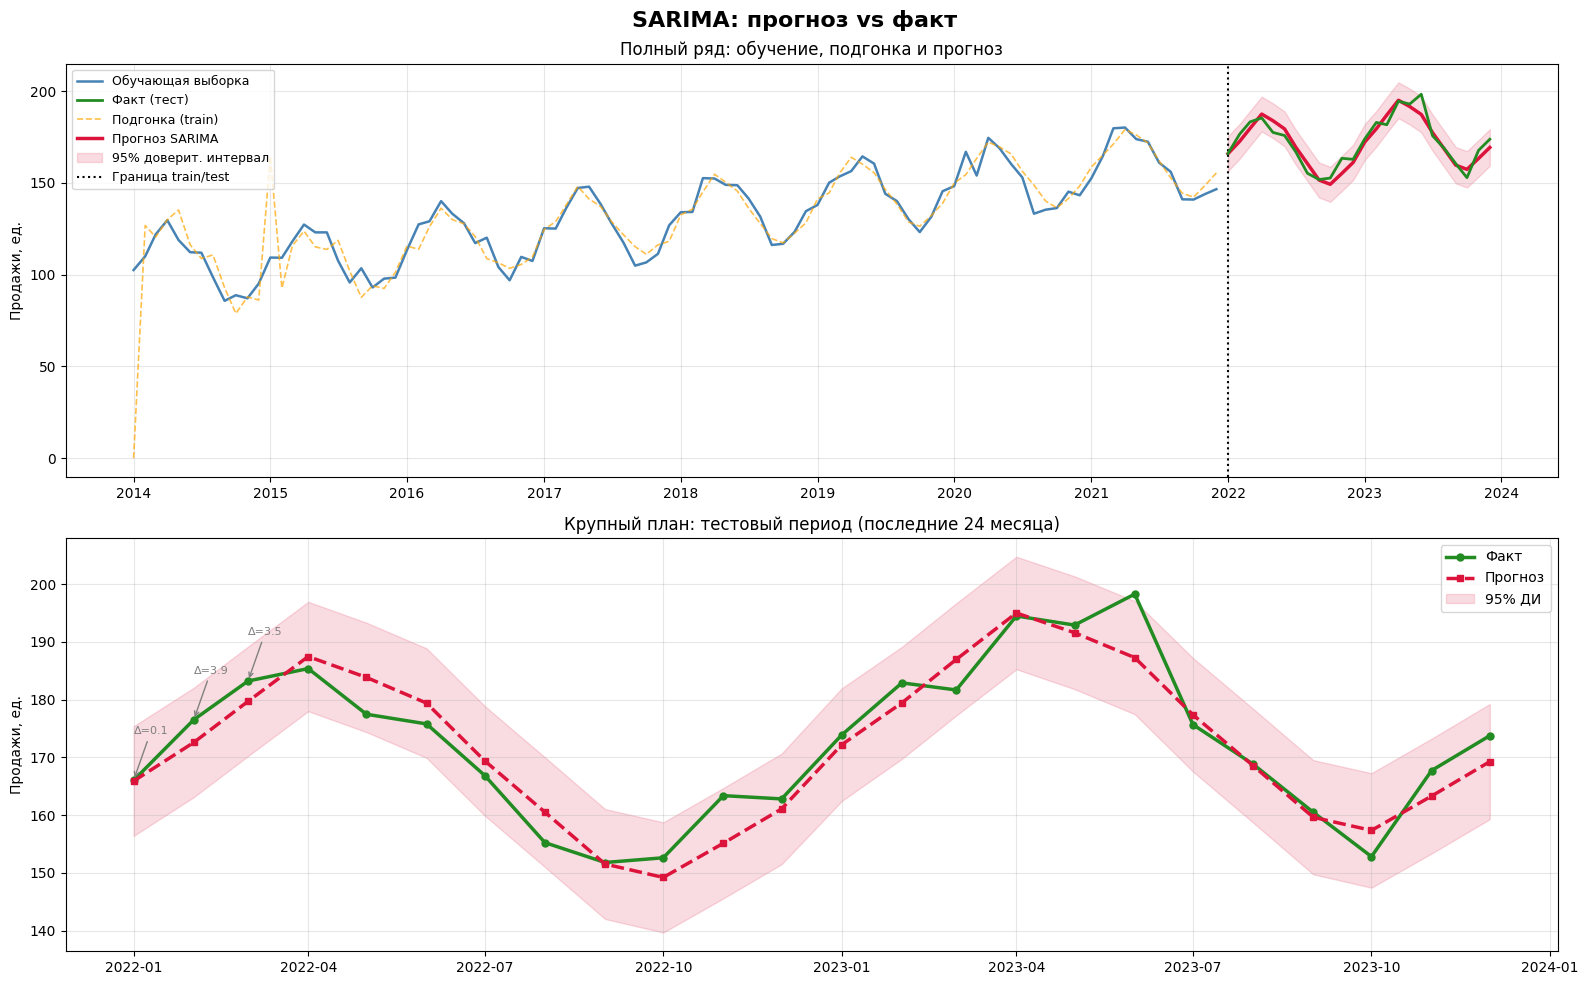

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Обучение финальной модели
# ══════════════════════════════════════════════════════════════════════════════

model_final = SARIMAX(
    train,
    order=best_params['order'],
    seasonal_order=best_params['seasonal_order'],
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_final = model_final.fit(disp=False)

print(fit_final.summary())

# ── Прогноз на тестовый период ─────────────────────────────────────────────
forecast_obj = fit_final.get_forecast(steps=TEST_SIZE)
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int(alpha=0.05)   # 95% доверительный интервал

# ── In-sample (подгонка на обучающей выборке) ──────────────────────────────
fitted_values = fit_final.fittedvalues

# ══════════════════════════════════════════════════════════════════════════════
# Визуализация: факт vs прогноз
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('SARIMA: прогноз vs факт', fontsize=16, fontweight='bold')

# ── График 1: полная картина ───────────────────────────────────────────────
ax = axes[0]
ax.plot(train, color='steelblue', linewidth=1.8, label='Обучающая выборка')
ax.plot(test,  color='forestgreen', linewidth=2, label='Факт (тест)',  zorder=5)
ax.plot(fitted_values, color='orange', linewidth=1.2, alpha=0.7,
        linestyle='--', label='Подгонка (train)')
ax.plot(forecast_mean, color='crimson', linewidth=2.5, label='Прогноз SARIMA')
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='crimson', alpha=0.15, label='95% доверит. интервал'
)
ax.axvline(x=test.index[0], color='black', linestyle=':', linewidth=1.5,
           label='Граница train/test')
ax.set_title('Полный ряд: обучение, подгонка и прогноз')
ax.set_ylabel('Продажи, ед.')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# ── График 2: крупный план — тестовый период ──────────────────────────────
ax = axes[1]
ax.plot(test, color='forestgreen', linewidth=2.5, marker='o',
        markersize=5, label='Факт')
ax.plot(forecast_mean, color='crimson', linewidth=2.5, marker='s',
        markersize=5, linestyle='--', label='Прогноз')
ax.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color='crimson', alpha=0.15, label='95% ДИ'
)
# Стрелки с отклонением для первых 3 точек
for i in range(3):
    ax.annotate(
        f'Δ={test.iloc[i] - forecast_mean.iloc[i]:.1f}',
        xy=(test.index[i], test.iloc[i]),
        xytext=(test.index[i], test.iloc[i] + 8),
        arrowprops=dict(arrowstyle='->', color='gray'),
        fontsize=8, color='gray'
    )
ax.set_title('Крупный план: тестовый период (последние 24 месяца)')
ax.set_ylabel('Продажи, ед.')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_forecast.png', dpi=150, bbox_inches='tight')
plt.show()



📊 Метрики качества прогноза (тестовая выборка)
  MAE  = 3.36  (средняя абсолютная ошибка)
  RMSE = 4.25  (корень из среднеквадр. ошибки)
  MAPE = 1.94% (средняя абсолютная ошибка в %)


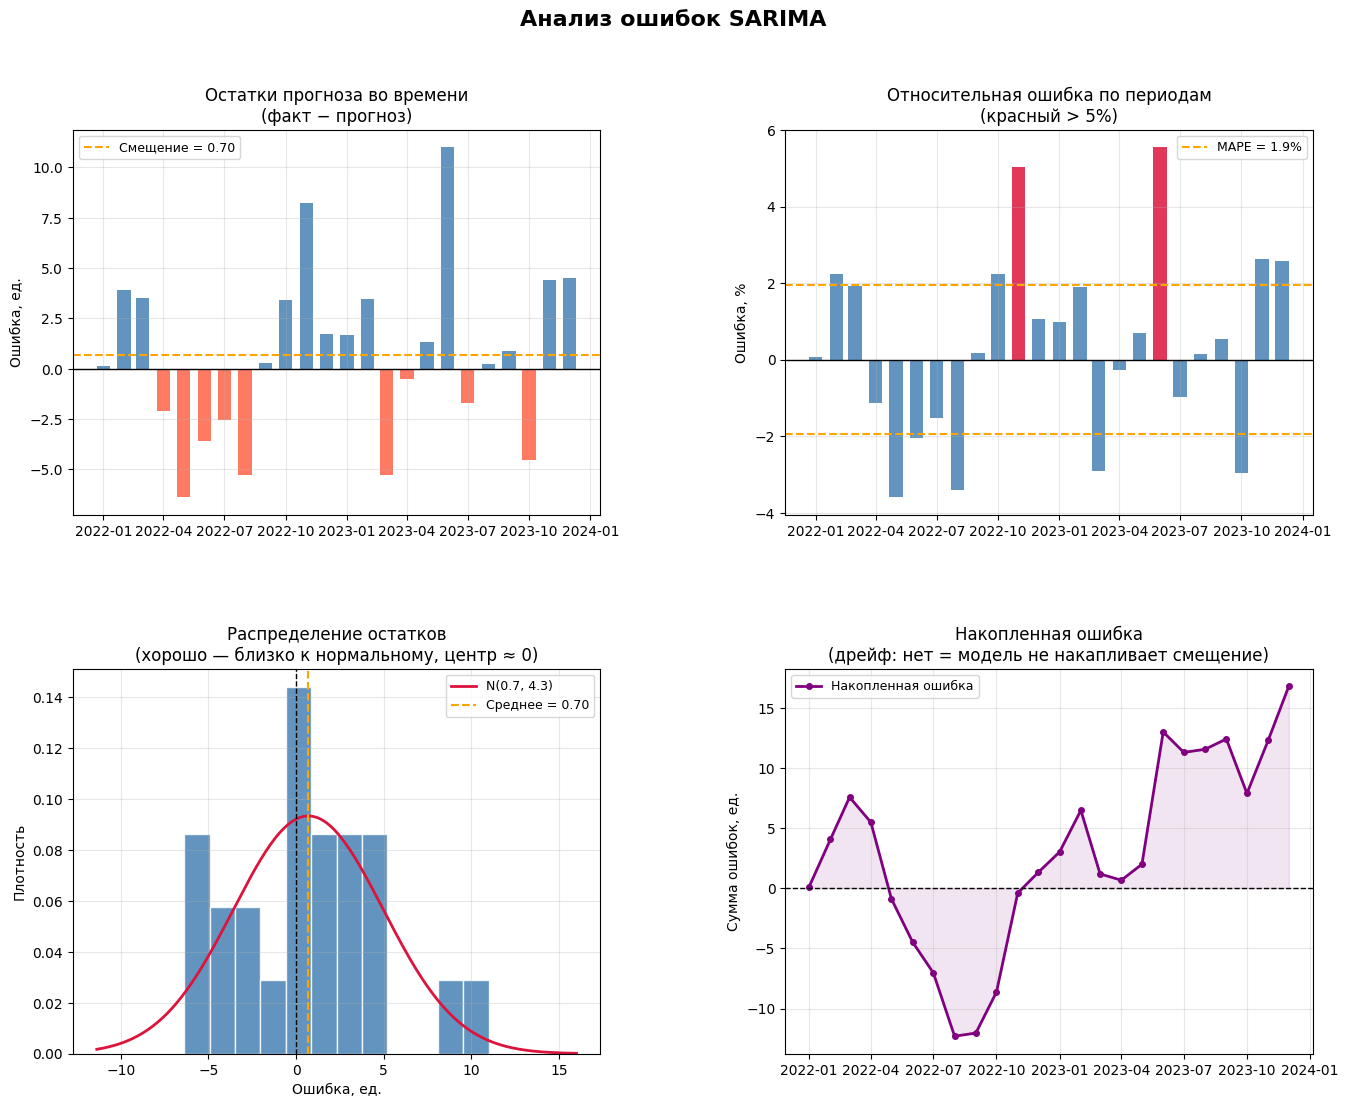

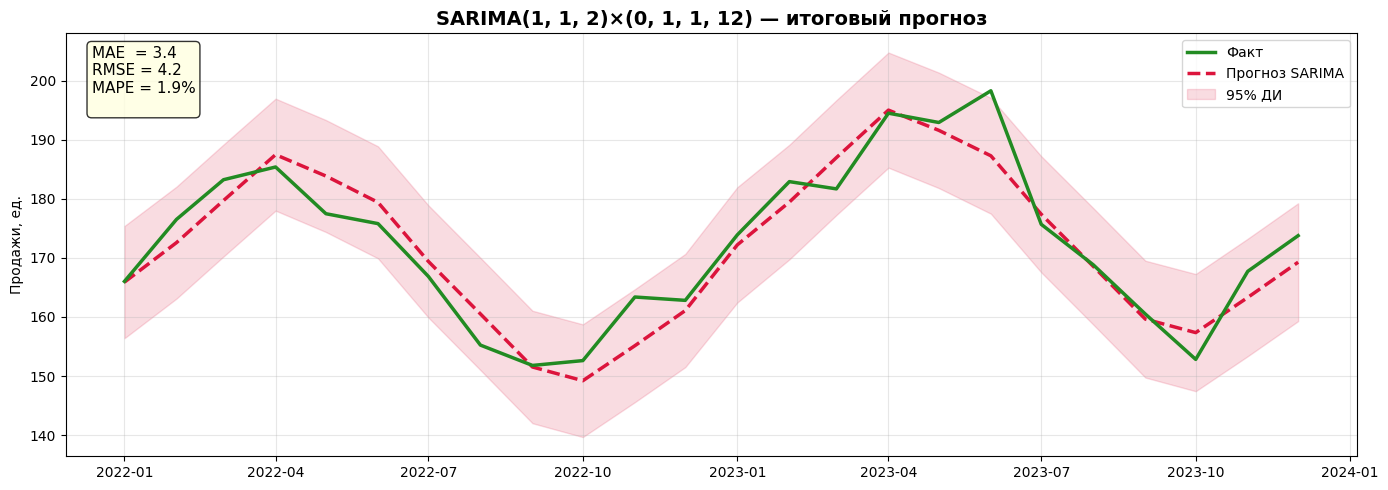

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Вычисление метрик
# ══════════════════════════════════════════════════════════════════════════════

errors     = test - forecast_mean          # остатки
errors_pct = (errors / test) * 100        # ошибка в %

mae  = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = np.mean(np.abs(errors_pct))



print("\n📊 Метрики качества прогноза (тестовая выборка)")
print(f"  MAE  = {mae:.2f}  (средняя абсолютная ошибка)")
print(f"  RMSE = {rmse:.2f}  (корень из среднеквадр. ошибки)")
print(f"  MAPE = {mape:.2f}% (средняя абсолютная ошибка в %)")


# ══════════════════════════════════════════════════════════════════════════════
# Визуализация ошибок — 4 графика
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Анализ ошибок SARIMA', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── График 1: остатки во времени ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(errors.index, errors.values,
        color=['tomato' if e < 0 else 'steelblue' for e in errors],
        alpha=0.85, width=20)
ax1.axhline(0,    color='black', linewidth=1)
ax1.axhline(bias, color='orange', linewidth=1.5, linestyle='--',
            label=f'Смещение = {bias:.2f}')
ax1.set_title('Остатки прогноза во времени\n(факт − прогноз)')
ax1.set_ylabel('Ошибка, ед.')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── График 2: MAPE по месяцам ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
colors_mape = ['crimson' if abs(v) > 5 else 'steelblue' for v in errors_pct]
ax2.bar(errors_pct.index, errors_pct.values, color=colors_mape, alpha=0.85, width=20)
ax2.axhline(0,     color='black',  linewidth=1)
ax2.axhline( mape, color='orange', linewidth=1.5, linestyle='--',
             label=f'MAPE = {mape:.1f}%')
ax2.axhline(-mape, color='orange', linewidth=1.5, linestyle='--')
ax2.set_title('Относительная ошибка по периодам\n(красный > 5%)')
ax2.set_ylabel('Ошибка, %')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# ── График 3: гистограмма остатков (нормальность) ─────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(errors.values, bins=12, color='steelblue', edgecolor='white',
         alpha=0.85, density=True)
# Наложим нормальное распределение для сравнения
from scipy.stats import norm
mu_e, std_e = errors.mean(), errors.std()
x_range = np.linspace(errors.min() - 5, errors.max() + 5, 200)
ax3.plot(x_range, norm.pdf(x_range, mu_e, std_e),
         color='crimson', linewidth=2, label=f'N({mu_e:.1f}, {std_e:.1f})')
ax3.axvline(0,    color='black',  linewidth=1, linestyle='--')
ax3.axvline(mu_e, color='orange', linewidth=1.5, linestyle='--',
            label=f'Среднее = {mu_e:.2f}')
ax3.set_title('Распределение остатков\n(хорошо — близко к нормальному, центр ≈ 0)')
ax3.set_xlabel('Ошибка, ед.')
ax3.set_ylabel('Плотность')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# ── График 4: накопленная ошибка (drift) ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
cumulative_error = errors.cumsum()
ax4.plot(cumulative_error, color='purple', linewidth=2, marker='o',
         markersize=4, label='Накопленная ошибка')
ax4.fill_between(cumulative_error.index, 0, cumulative_error,
                 color='purple', alpha=0.1)
ax4.axhline(0, color='black', linewidth=1, linestyle='--')
ax4.set_title('Накопленная ошибка\n(дрейф: нет = модель не накапливает смещение)')
ax4.set_ylabel('Сумма ошибок, ед.')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

plt.savefig('04_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Итоговый дашборд — одна картинка для слайда
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test, color='forestgreen', linewidth=2.5, label='Факт', zorder=5)
ax.plot(forecast_mean, color='crimson', linewidth=2.5,
        linestyle='--', label='Прогноз SARIMA')
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                color='crimson', alpha=0.15, label='95% ДИ')

# Метрики прямо на графике
metrics_text = (
    f"MAE  = {mae:.1f}\n"
    f"RMSE = {rmse:.1f}\n"
    f"MAPE = {mape:.1f}%\n"
)
ax.text(0.02, 0.97, metrics_text,
        transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.set_title(
    f'SARIMA{best_params["order"]}×{best_params["seasonal_order"]} — итоговый прогноз',
    fontsize=14, fontweight='bold'
)
ax.set_ylabel('Продажи, ед.')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('05_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


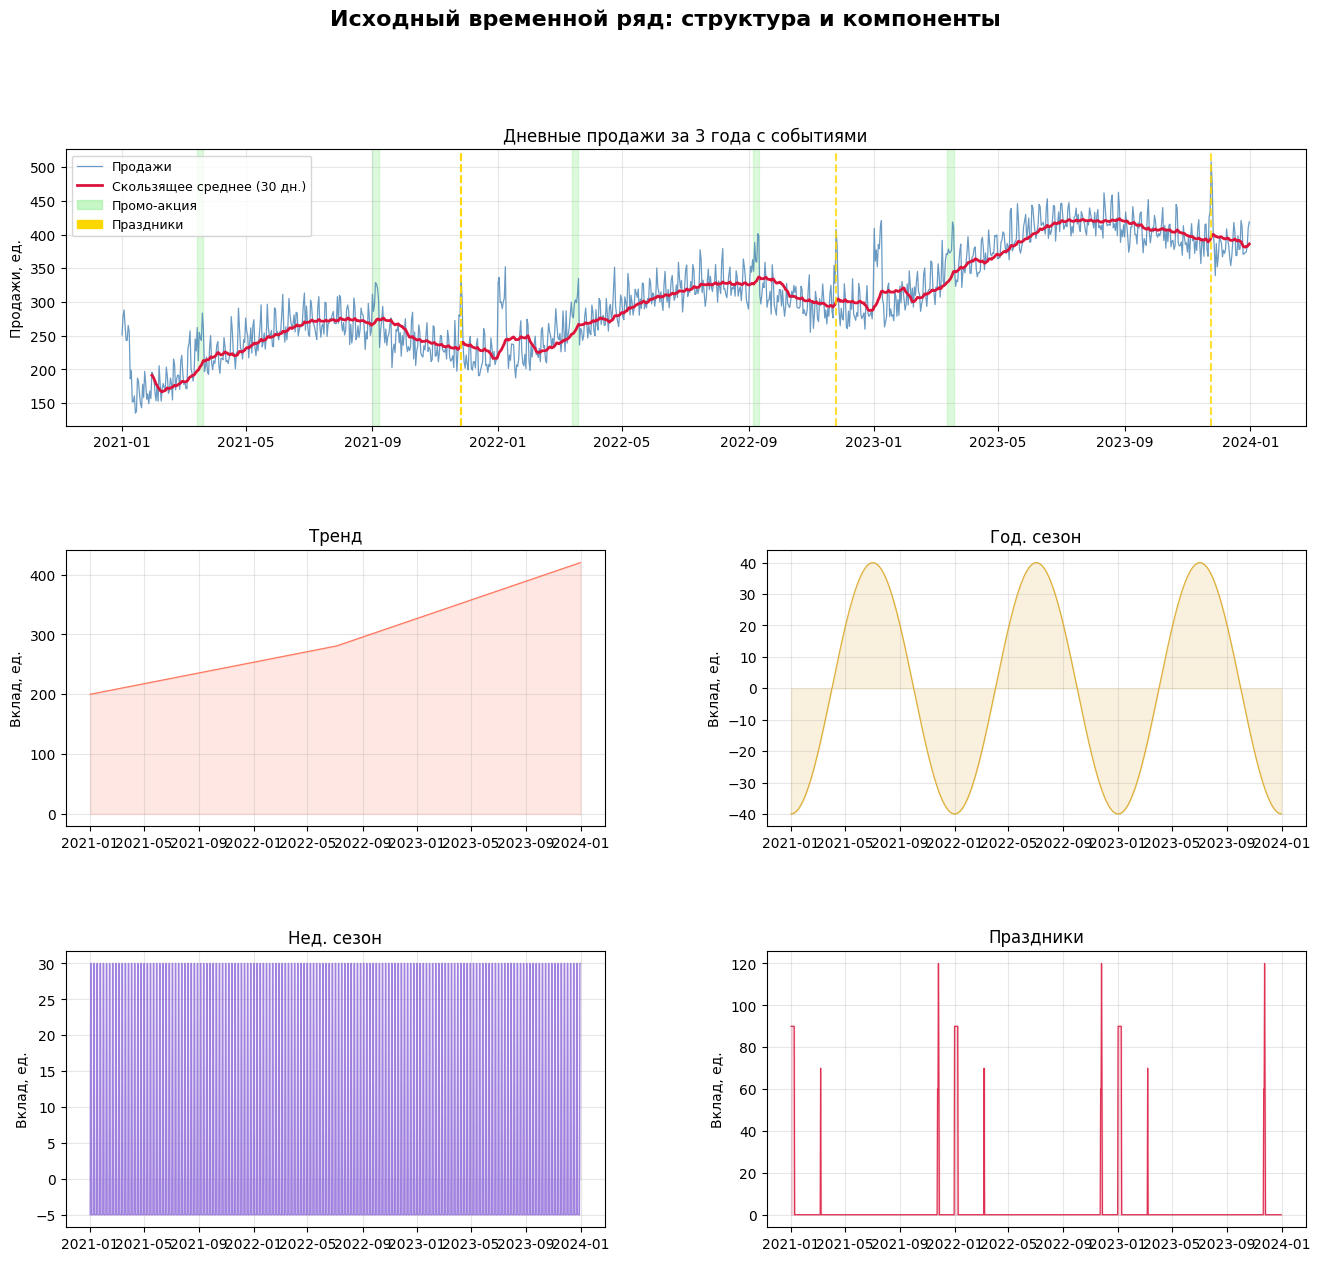

📅 Период: 2021-01-01 → 2023-12-31
📏 Длина:  1095 дней
📊 Среднее: 305.1  |  Std: 72.7
📈 Мин: 134.9  |  Макс: 507.9


In [ ]:
###################
# PROPHET
###################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── Воспроизводимость ──────────────────────────────────────────────────────────
np.random.seed(42)

# ── Параметры генерации ────────────────────────────────────────────────────────
N_PERIODS  = 365 * 3      # 3 года дневных наблюдений
TEST_SIZE  = 90           # последние 90 дней — тестовая выборка

# ── Генерация дат ──────────────────────────────────────────────────────────────
dates = pd.date_range(start='2021-01-01', periods=N_PERIODS, freq='D')

# ── Компоненты ряда ────────────────────────────────────────────────────────────
# Тренд с изломом: сначала медленный рост, потом ускорение
trend = np.concatenate([
    np.linspace(200, 280, N_PERIODS // 2),
    np.linspace(280, 420, N_PERIODS - N_PERIODS // 2)
])

# Годовая сезонность: зима и лето — пики продаж
day_of_year = np.arange(N_PERIODS) % 365
annual      = 40 * np.sin(2 * np.pi * day_of_year / 365 - np.pi / 2)

# Недельная сезонность: выходные дают прирост
day_of_week = pd.Series(dates).dt.dayofweek.values
weekly      = np.where(day_of_week >= 5, 30, -5)   # сб/вс +30, будни -5

# Шум
noise = np.random.normal(0, 12, N_PERIODS)

# ── Эффект праздников ─────────────────────────────────────────────────────────
holiday_effect = np.zeros(N_PERIODS)

# Новогодние праздники (1–8 января каждого года)
for year in [2021, 2022, 2023]:
    for day_offset in range(8):
        date = pd.Timestamp(f'{year}-01-01') + pd.Timedelta(days=day_offset)
        if date in dates:
            idx = dates.get_loc(date)
            holiday_effect[idx] = 90    # сильный всплеск

# Чёрная пятница (4-я пятница ноября)
black_fridays = ['2021-11-26', '2022-11-25', '2023-11-24']
for bf in black_fridays:
    bf_ts = pd.Timestamp(bf)
    for delta in [-2, -1, 0, 1]:      # за 2 дня до и 1 день после
        d = bf_ts + pd.Timedelta(days=delta)
        if d in dates:
            idx = dates.get_loc(d)
            holiday_effect[idx] = 120 if delta == 0 else 60

# 8 марта
march_8_dates = ['2021-03-08', '2022-03-08', '2023-03-08']
for m8 in march_8_dates:
    d = pd.Timestamp(m8)
    if d in dates:
        idx = dates.get_loc(d)
        holiday_effect[idx] = 70

# ── Промо-акции (запланированные кампании) ────────────────────────────────────
promo_effect = np.zeros(N_PERIODS)

promo_periods = [
    ('2021-03-15', '2021-03-21'),
    ('2021-09-01', '2021-09-07'),
    ('2022-03-14', '2022-03-20'),
    ('2022-09-05', '2022-09-11'),
    ('2023-03-13', '2023-03-19'),
]
for start, end in promo_periods:
    mask = (dates >= start) & (dates <= end)
    promo_effect[mask] = 50     # +50 единиц в период акции

# ── Итоговый ряд ──────────────────────────────────────────────────────────────
values = trend + annual + weekly + holiday_effect + promo_effect + noise
values = np.clip(values, 0, None)    # продажи не могут быть отрицательными

series = pd.Series(values, index=dates, name='Sales')

# ══════════════════════════════════════════════════════════════════════════════
# Визуализация исходного ряда
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 14))
fig.suptitle('Исходный временной ряд: структура и компоненты',
             fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── График 1: полный ряд с аннотацией событий ─────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(series, color='steelblue', linewidth=0.9, alpha=0.8, label='Продажи')
ax1.plot(series.rolling(30).mean(), color='crimson', linewidth=2,
         label='Скользящее среднее (30 дн.)')

# Отметки праздников
for bf in black_fridays:
    ax1.axvline(pd.Timestamp(bf), color='gold', linewidth=1.5,
                linestyle='--', alpha=0.8)
ax1.axvline(pd.Timestamp(black_fridays[0]), color='gold', linewidth=1.5,
            linestyle='--', alpha=0.8, label='Чёрная пятница')

# Отметки промо
for start, end in promo_periods:
    ax1.axvspan(start, end, color='lightgreen', alpha=0.3)
green_patch = mpatches.Patch(color='lightgreen', alpha=0.5, label='Промо-акция')

ax1.set_title('Дневные продажи за 3 года с событиями')
ax1.set_ylabel('Продажи, ед.')
ax1.legend(handles=[*ax1.lines[:2], green_patch,
                    mpatches.Patch(color='gold', label='Праздники')],
           fontsize=9, loc='upper left')
ax1.grid(alpha=0.3)

# ── График 2: компоненты ──────────────────────────────────────────────────
components = {
    'Тренд':       (trend,          'tomato',    gs[1, 0]),
    'Год. сезон':  (annual,         'goldenrod', gs[1, 1]),
    'Нед. сезон':  (weekly,         'mediumpurple', gs[2, 0]),
    'Праздники':   (holiday_effect, 'crimson',   gs[2, 1]),
}
for title, (comp, color, pos) in components.items():
    ax = fig.add_subplot(pos)
    ax.plot(dates, comp, color=color, linewidth=0.9, alpha=0.85)
    ax.fill_between(dates, 0, comp, color=color, alpha=0.15)
    ax.set_title(title)
    ax.set_ylabel('Вклад, ед.')
    ax.grid(alpha=0.3)

plt.savefig('p01_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📅 Период: {series.index[0].date()} → {series.index[-1].date()}")
print(f"📏 Длина:  {len(series)} дней")
print(f"📊 Среднее: {series.mean():.1f}  |  Std: {series.std():.1f}")
print(f"📈 Мин: {series.min():.1f}  |  Макс: {series.max():.1f}")


Train: 1005 строк  |  Test: 90 строк

📋 Таблица событий для Prophet:
                   кол-во дней
holiday                       
black_friday                 4
march_8                      4
new_year_holidays           32
promo_campaign              35

Всего строк в таблице событий: 75


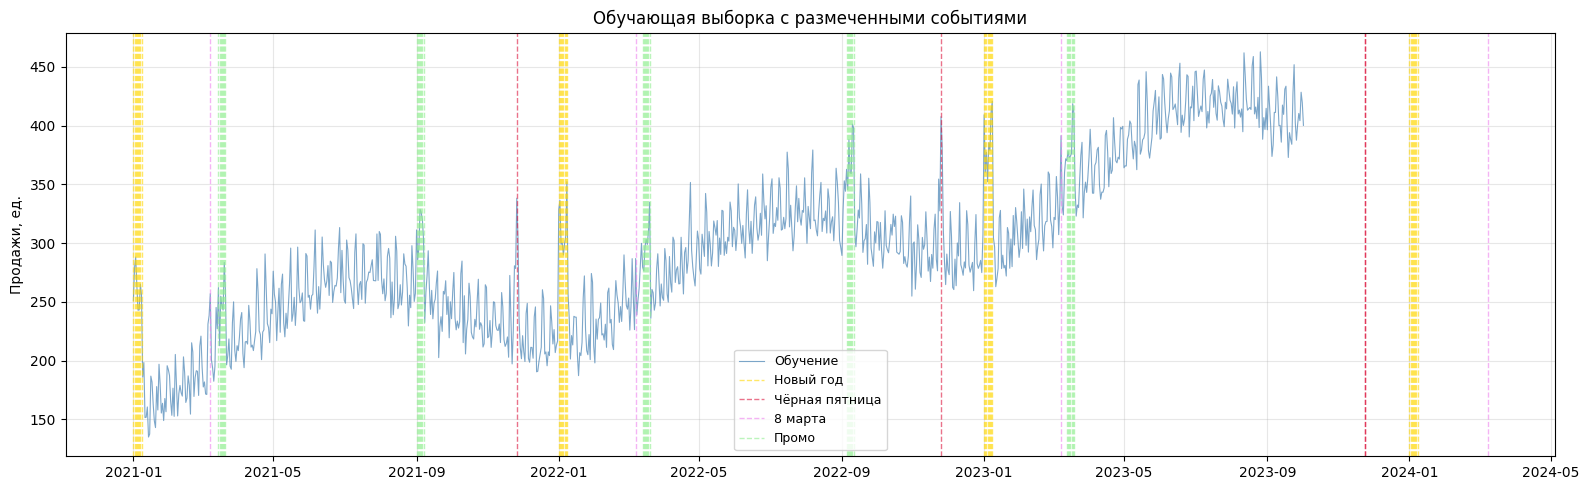

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Prophet ожидает DataFrame с колонками ds (дата) и y (значение)
# ══════════════════════════════════════════════════════════════════════════════

df = pd.DataFrame({'ds': series.index, 'y': series.values})

train_df = df.iloc[:-TEST_SIZE].copy()
test_df  = df.iloc[-TEST_SIZE:].copy()

print(f"Train: {len(train_df)} строк  |  Test: {len(test_df)} строк")

# ══════════════════════════════════════════════════════════════════════════════
# Формирование таблицы праздников для Prophet
# ══════════════════════════════════════════════════════════════════════════════

# ── Новогодние каникулы ───────────────────────────────────────────────────────
new_year_dates = []
for year in [2021, 2022, 2023, 2024]:       # +2024 для прогноза вперёд
    for day in range(8):
        new_year_dates.append(
            pd.Timestamp(f'{year}-01-01') + pd.Timedelta(days=day)
        )

new_year = pd.DataFrame({
    'holiday':    'new_year_holidays',
    'ds':          pd.to_datetime(new_year_dates),
    'lower_window': 0,
    'upper_window': 0,
})

# ── Чёрная пятница (+ предпраздничные и послепраздничные дни) ─────────────────
black_friday = pd.DataFrame({
    'holiday':    'black_friday',
    'ds':          pd.to_datetime(black_fridays + ['2023-11-24']),
    'lower_window': -2,     # захватываем 2 дня ДО
    'upper_window':  1,     # и 1 день ПОСЛЕ
})

# ── 8 марта ───────────────────────────────────────────────────────────────────
march_8 = pd.DataFrame({
    'holiday':    'march_8',
    'ds':          pd.to_datetime(march_8_dates + ['2024-03-08']),
    'lower_window': -1,     # день накануне тоже важен
    'upper_window':  0,
})

# ── Промо-акции как отдельный тип события ─────────────────────────────────────
all_promo_dates = []
for start, end in promo_periods:
    promo_range = pd.date_range(start=start, end=end, freq='D')
    all_promo_dates.extend(promo_range)

promo = pd.DataFrame({
    'holiday':    'promo_campaign',
    'ds':          pd.to_datetime(all_promo_dates),
    'lower_window': 0,
    'upper_window': 0,
})

# ── Объединяем все события ────────────────────────────────────────────────────
holidays_df = pd.concat([new_year, black_friday, march_8, promo],
                        ignore_index=True)

print("\n📋 Таблица событий для Prophet:")
print(holidays_df.groupby('holiday')['ds'].count().rename('кол-во дней').to_frame())
print(f"\nВсего строк в таблице событий: {len(holidays_df)}")

# ── Визуализация: какие события попали в обучающую выборку ────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_df['ds'], train_df['y'],
        color='steelblue', linewidth=0.8, alpha=0.7, label='Обучение')

event_colors = {
    'new_year_holidays': ('gold',       'Новый год'),
    'black_friday':      ('crimson',    'Чёрная пятница'),
    'march_8':           ('violet',     '8 марта'),
    'promo_campaign':    ('lightgreen', 'Промо'),
}
plotted = set()
for _, row in holidays_df.iterrows():
    color, label = event_colors[row['holiday']]
    lbl = label if row['holiday'] not in plotted else '_nolegend_'
    ax.axvline(row['ds'], color=color, linewidth=1,
               alpha=0.6, linestyle='--', label=lbl)
    plotted.add(row['holiday'])

ax.set_title('Обучающая выборка с размеченными событиями')
ax.set_ylabel('Продажи, ед.')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('p02_holidays_markup.png', dpi=150, bbox_inches='tight')
plt.show()


✅ Обе модели обучены


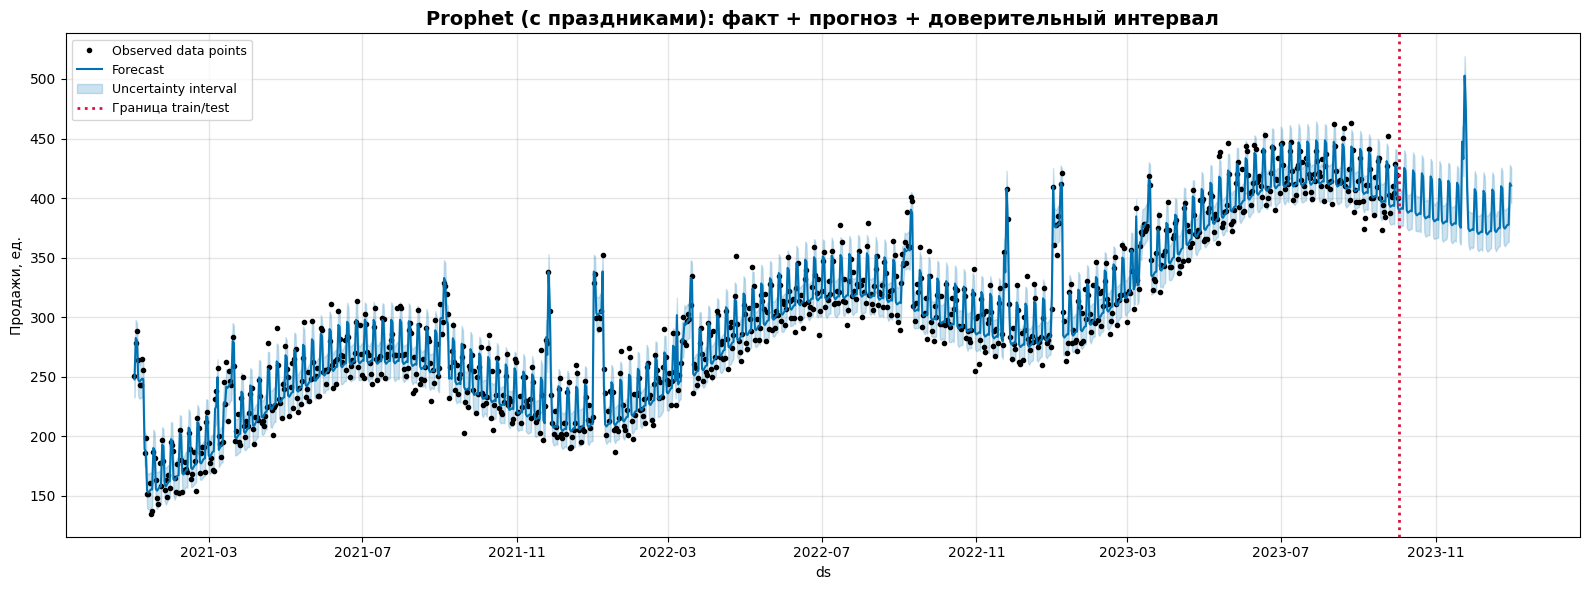

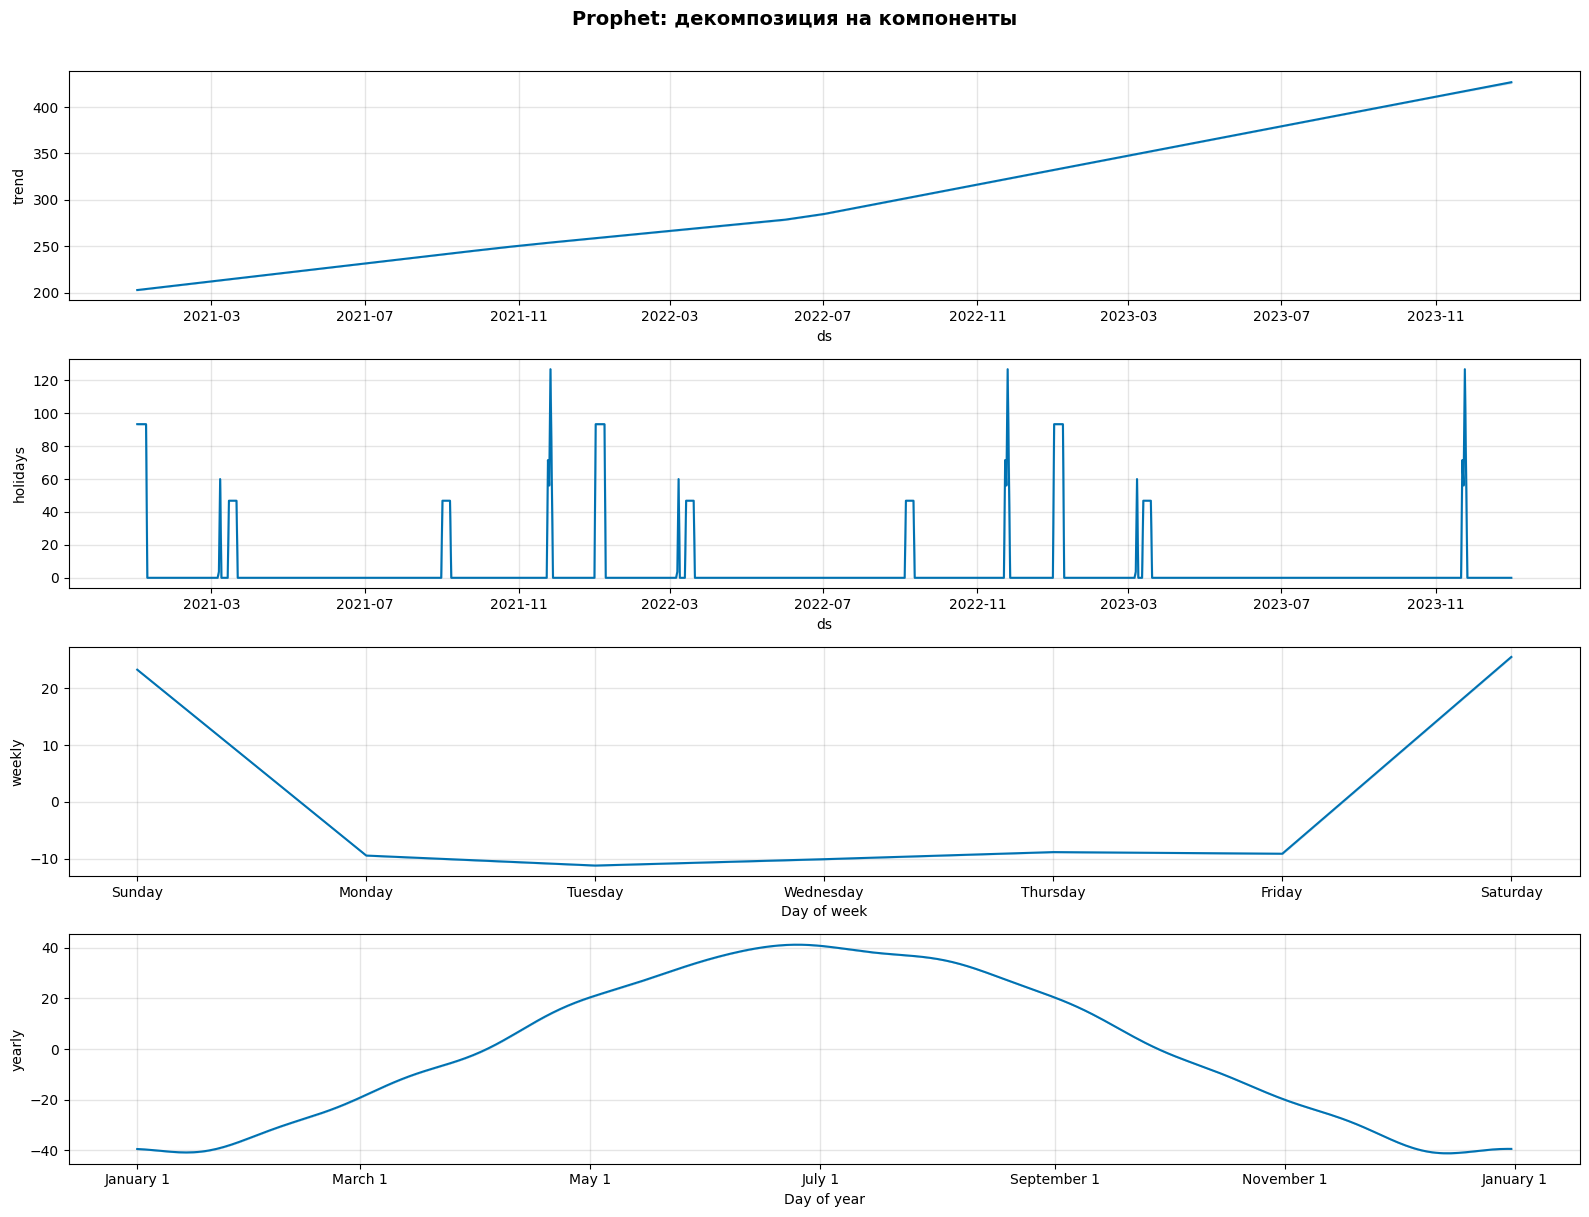

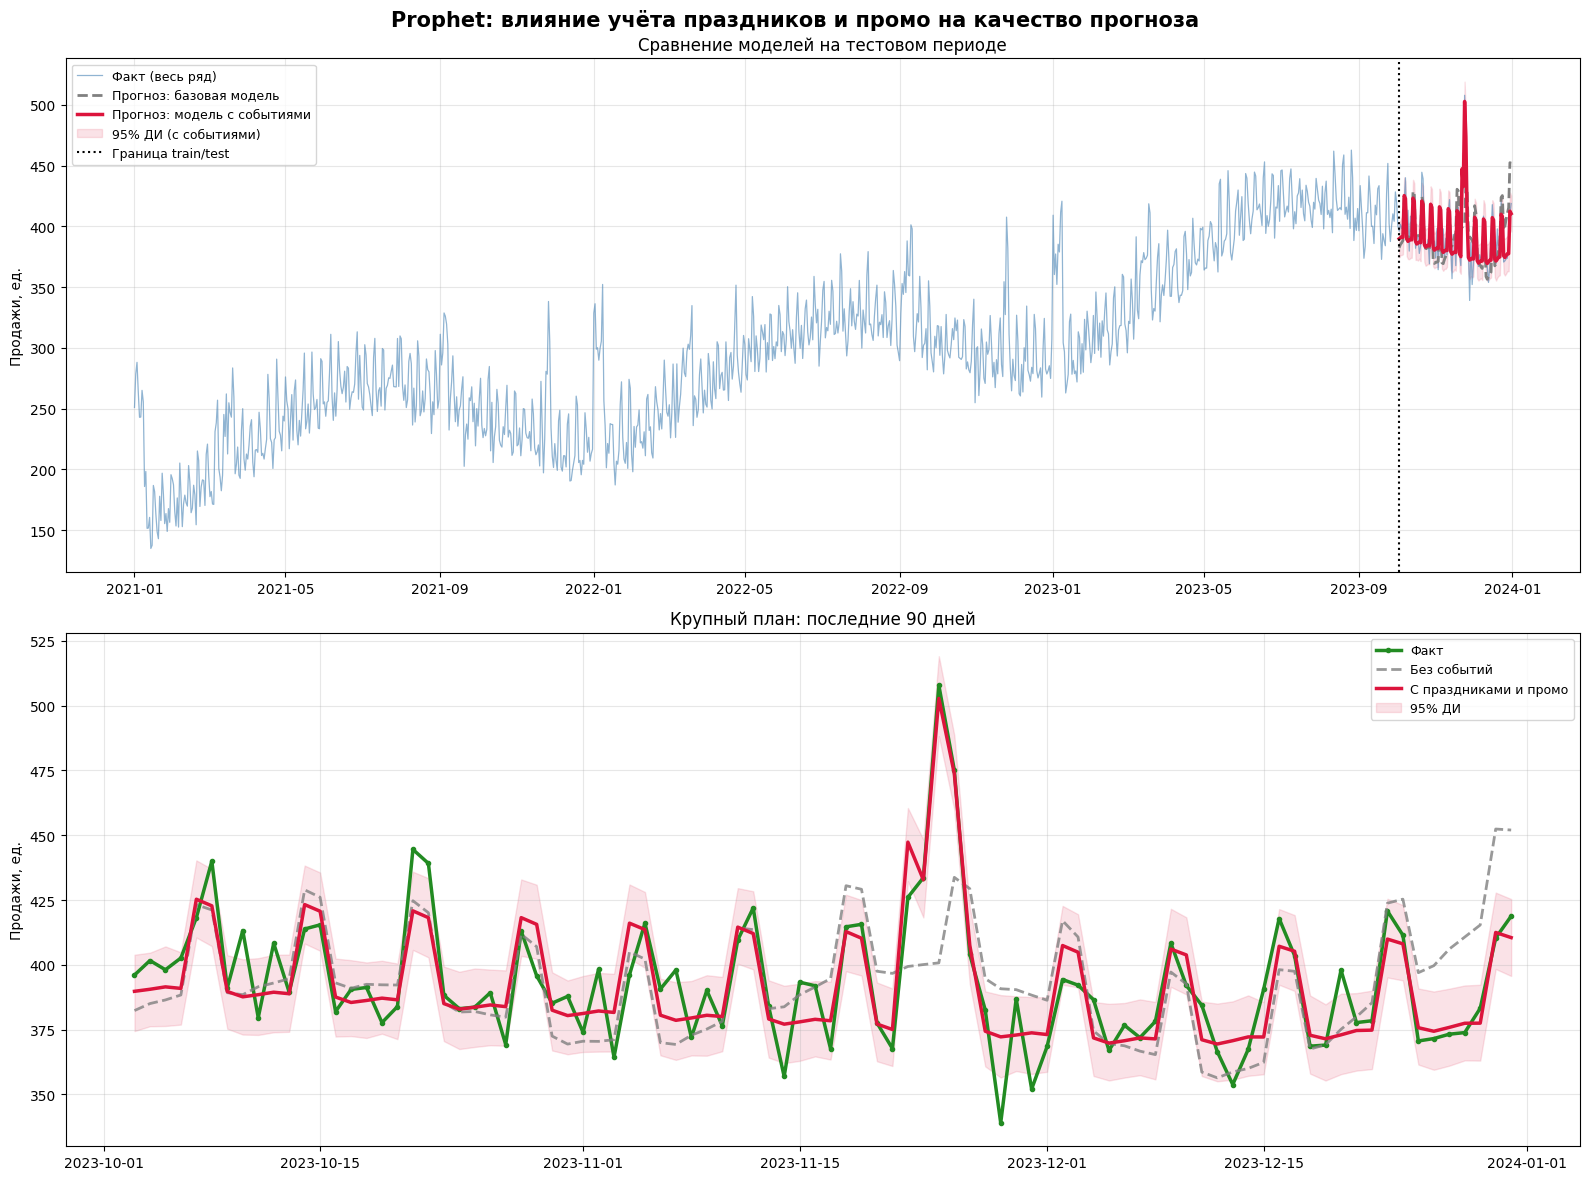

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Две модели: без праздников и с праздниками — сравниваем влияние
# ══════════════════════════════════════════════════════════════════════════════

# ── Модель 1: базовая (без событий) ──────────────────────────────────────────
model_base = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    seasonality_mode    = 'additive',   # additive: эффекты суммируются
    changepoint_prior_scale = 0.05,     # гибкость тренда (0.05 — умеренная)
)
model_base.fit(train_df)

# ── Модель 2: с праздниками и промо ──────────────────────────────────────────
model_full = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    seasonality_mode    = 'additive',
    changepoint_prior_scale = 0.05,
    holidays            = holidays_df,
)
model_full.fit(train_df)

print("✅ Обе модели обучены")

# ── Создаём датафрейм для прогноза ────────────────────────────────────────────
# make_future_dataframe включает и обучающий период, и горизонт прогноза
future_base = model_base.make_future_dataframe(periods=TEST_SIZE, freq='D')
future_full = model_full.make_future_dataframe(periods=TEST_SIZE, freq='D')

forecast_base = model_base.predict(future_base)
forecast_full = model_full.predict(future_full)

# ── Срезаем только тестовый период ────────────────────────────────────────────
test_start    = test_df['ds'].iloc[0]
fc_base_test  = forecast_base[forecast_base['ds'] >= test_start].copy()
fc_full_test  = forecast_full[forecast_full['ds'] >= test_start].copy()

# ══════════════════════════════════════════════════════════════════════════════
# Визуализация 1: встроенный plot Prophet (быстро и наглядно)
# ══════════════════════════════════════════════════════════════════════════════

fig1 = model_full.plot(forecast_full, figsize=(16, 6))
fig1.axes[0].set_title(
    'Prophet (с праздниками): факт + прогноз + доверительный интервал',
    fontsize=14, fontweight='bold'
)
fig1.axes[0].set_ylabel('Продажи, ед.')
# Вертикальная черта — граница train/test
fig1.axes[0].axvline(test_start, color='crimson', linewidth=2,
                     linestyle=':', label='Граница train/test')
fig1.axes[0].legend(fontsize=9)
plt.tight_layout()
plt.savefig('p03a_prophet_builtin_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Визуализация 2: декомпозиция компонент (встроенная в Prophet)
# ══════════════════════════════════════════════════════════════════════════════

fig2 = model_full.plot_components(forecast_full, figsize=(16, 12))
fig2.suptitle('Prophet: декомпозиция на компоненты',
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('p03b_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Визуализация 3: сравнение базовой модели и модели с событиями
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Prophet: влияние учёта праздников и промо на качество прогноза',
             fontsize=15, fontweight='bold')

# ── Верхний: полная картина ────────────────────────────────────────────────
ax = axes[0]
ax.plot(df['ds'], df['y'],
        color='steelblue', linewidth=0.9, alpha=0.6, label='Факт (весь ряд)')
ax.plot(fc_base_test['ds'], fc_base_test['yhat'],
        color='gray', linewidth=2, linestyle='--',
        label='Прогноз: базовая модель')
ax.plot(fc_full_test['ds'], fc_full_test['yhat'],
        color='crimson', linewidth=2.5,
        label='Прогноз: модель с событиями')
ax.fill_between(fc_full_test['ds'],
                fc_full_test['yhat_lower'],
                fc_full_test['yhat_upper'],
                color='crimson', alpha=0.12, label='95% ДИ (с событиями)')
ax.axvline(test_start, color='black', linewidth=1.5,
           linestyle=':', label='Граница train/test')
ax.set_title('Сравнение моделей на тестовом периоде')
ax.set_ylabel('Продажи, ед.')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)

# ── Нижний: крупный план тестового периода ────────────────────────────────
ax = axes[1]
ax.plot(test_df['ds'], test_df['y'],
        color='forestgreen', linewidth=2.5, marker='o', markersize=3,
        label='Факт')
ax.plot(fc_base_test['ds'], fc_base_test['yhat'],
        color='gray', linewidth=2, linestyle='--', alpha=0.8,
        label='Без событий')
ax.plot(fc_full_test['ds'], fc_full_test['yhat'],
        color='crimson', linewidth=2.5,
        label='С праздниками и промо')
ax.fill_between(fc_full_test['ds'],
                fc_full_test['yhat_lower'],
                fc_full_test['yhat_upper'],
                color='crimson', alpha=0.12, label='95% ДИ')

# Подсвечиваем промо в тестовом периоде (если попали)
for start, end in promo_periods:
    if pd.Timestamp(end) >= test_start:
        ax.axvspan(max(start, str(test_start.date())), end,
                   color='lightgreen', alpha=0.3)

ax.set_title('Крупный план: последние 90 дней')
ax.set_ylabel('Продажи, ед.')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('p03c_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



📊 Метрики: Базовая модель (без событий)
  MAE  = 15.78
  RMSE = 21.74
  MAPE = 3.95%
  Bias = -0.10

📊 Метрики: Модель с праздниками и промо
  MAE  = 8.92
  RMSE = 11.38
  MAPE = 2.28%
  Bias = 0.90

📈 Улучшение от учёта событий:
  MAE: ↓ 6.85
  RMSE: ↓ 10.36
  MAPE: ↓ 1.67


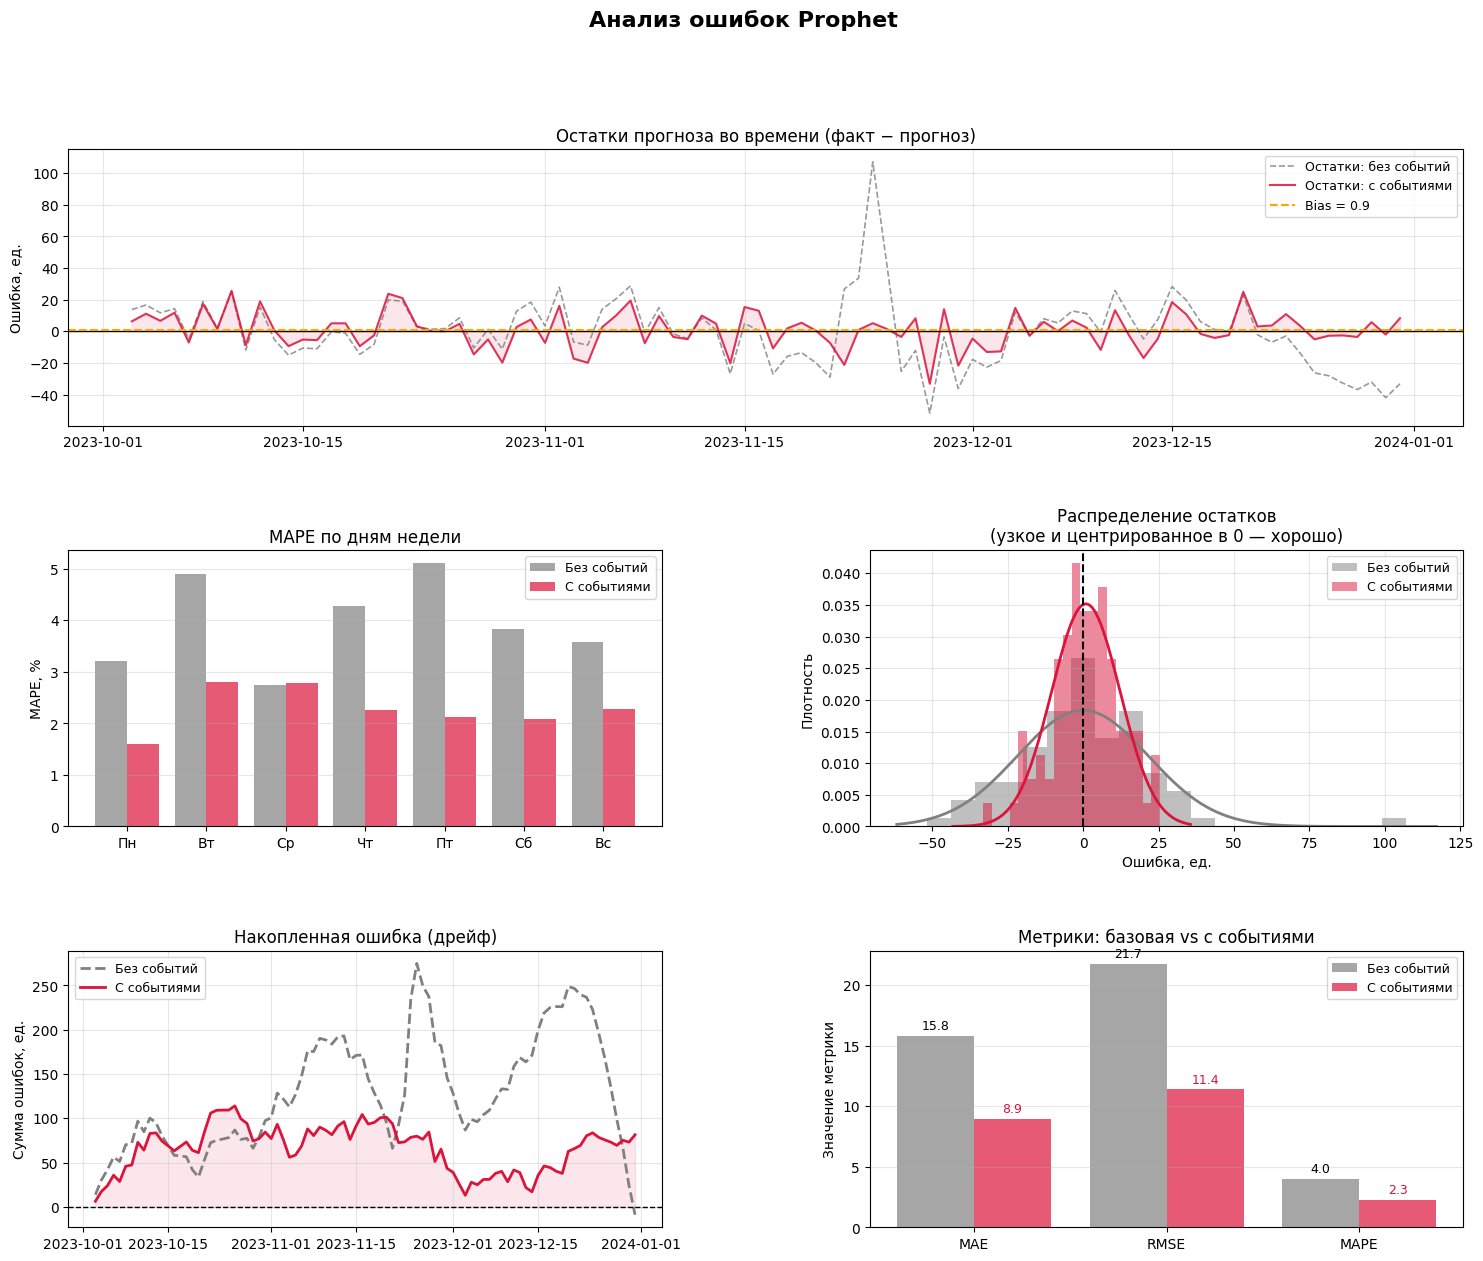

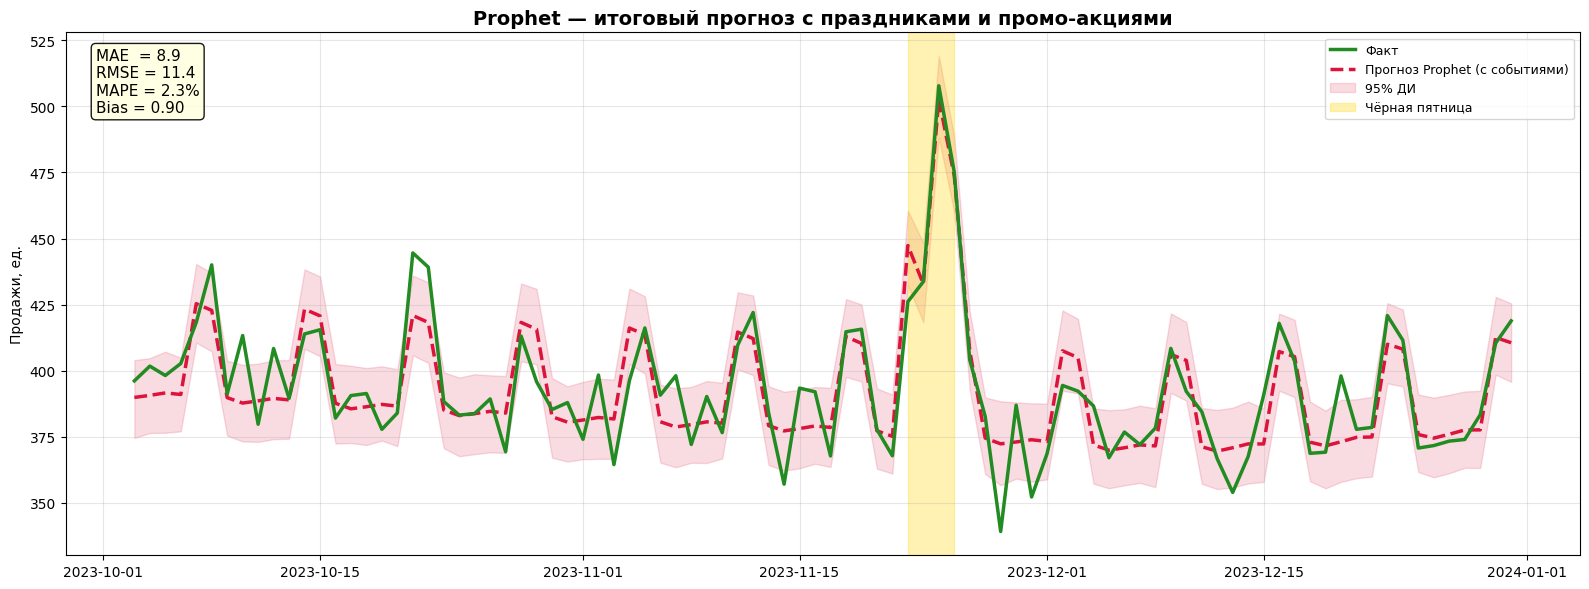

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Вычисление метрик для обеих моделей
# ══════════════════════════════════════════════════════════════════════════════

y_true      = test_df['y'].values
y_base      = fc_base_test['yhat'].values
y_full      = fc_full_test['yhat'].values

errors_base = y_true - y_base
errors_full = y_true - y_full

def metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    bias = np.mean(y_true - y_pred)
    print(f"\n📊 Метрики: {label}")
    print(f"  MAE  = {mae:.2f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  Bias = {bias:.2f}")
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Bias': bias}

m_base = metrics(y_true, y_base, 'Базовая модель (без событий)')
m_full = metrics(y_true, y_full, 'Модель с праздниками и промо')

improvement = {k: m_base[k] - m_full[k] for k in ['MAE', 'RMSE', 'MAPE']}
print(f"\n📈 Улучшение от учёта событий:")
for k, v in improvement.items():
    sign = '↓' if v > 0 else '↑'
    print(f"  {k}: {sign} {abs(v):.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# Визуализация ошибок — 6 графиков
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Анализ ошибок Prophet', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

dates_test = pd.to_datetime(test_df['ds'].values)

# ── График 1: остатки во времени — обе модели ─────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(dates_test, errors_base, color='gray', linewidth=1.2,
         alpha=0.8, linestyle='--', label='Остатки: без событий')
ax1.plot(dates_test, errors_full, color='crimson', linewidth=1.5,
         alpha=0.85, label='Остатки: с событиями')
ax1.fill_between(dates_test, errors_full, 0,
                 color='crimson', alpha=0.1)
ax1.axhline(0, color='black', linewidth=1)
ax1.axhline(errors_full.mean(), color='orange', linewidth=1.5,
            linestyle='--', label=f'Bias = {errors_full.mean():.1f}')
ax1.set_title('Остатки прогноза во времени (факт − прогноз)')
ax1.set_ylabel('Ошибка, ед.')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── График 2: MAPE по дням недели ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
test_dates_series = pd.Series(dates_test)
dow              = test_dates_series.dt.dayofweek.values
dow_names        = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
mape_by_dow_base = [np.mean(np.abs(errors_base[dow == d] / y_true[dow == d])) * 100
                    for d in range(7)]
mape_by_dow_full = [np.mean(np.abs(errors_full[dow == d] / y_true[dow == d])) * 100
                    for d in range(7)]
x = np.arange(7)
ax2.bar(x - 0.2, mape_by_dow_base, width=0.4,
        color='gray',   alpha=0.7, label='Без событий')
ax2.bar(x + 0.2, mape_by_dow_full, width=0.4,
        color='crimson', alpha=0.7, label='С событиями')
ax2.set_xticks(x)
ax2.set_xticklabels(dow_names)
ax2.set_title('MAPE по дням недели')
ax2.set_ylabel('MAPE, %')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis='y')

# ── График 3: гистограмма остатков ────────────────────────────────────────
from scipy.stats import norm

ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(errors_base, bins=20, color='gray',   alpha=0.5,
         density=True, label='Без событий')
ax3.hist(errors_full, bins=20, color='crimson', alpha=0.5,
         density=True, label='С событиями')
# Нормальное распределение для каждой модели
for errors, color in [(errors_base, 'gray'), (errors_full, 'crimson')]:
    mu, sd = errors.mean(), errors.std()
    x_r = np.linspace(errors.min() - 10, errors.max() + 10, 200)
    ax3.plot(x_r, norm.pdf(x_r, mu, sd), color=color, linewidth=2)
ax3.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax3.set_title('Распределение остатков\n(узкое и центрированное в 0 — хорошо)')
ax3.set_xlabel('Ошибка, ед.')
ax3.set_ylabel('Плотность')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# ── График 4: накопленная ошибка ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
cum_base = np.cumsum(errors_base)
cum_full = np.cumsum(errors_full)
ax4.plot(dates_test, cum_base, color='gray',   linewidth=2,
         linestyle='--', label='Без событий')
ax4.plot(dates_test, cum_full, color='crimson', linewidth=2,
         label='С событиями')
ax4.fill_between(dates_test, cum_full, 0, color='crimson', alpha=0.1)
ax4.axhline(0, color='black', linewidth=1, linestyle='--')
ax4.set_title('Накопленная ошибка (дрейф)')
ax4.set_ylabel('Сумма ошибок, ед.')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

# ── График 5: сравнение метрик двух моделей ───────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
metric_names = ['MAE', 'RMSE', 'MAPE']
vals_base    = [m_base[k] for k in metric_names]
vals_full    = [m_full[k] for k in metric_names]
x = np.arange(len(metric_names))
bars_b = ax5.bar(x - 0.2, vals_base, width=0.4,
                 color='gray',   alpha=0.7, label='Без событий')
bars_f = ax5.bar(x + 0.2, vals_full, width=0.4,
                 color='crimson', alpha=0.7, label='С событиями')
# Подписи значений
for bar in bars_b:
    ax5.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom', fontsize=9)
for bar in bars_f:
    ax5.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom', fontsize=9, color='crimson')
ax5.set_xticks(x)
ax5.set_xticklabels(metric_names)
ax5.set_title('Метрики: базовая vs с событиями')
ax5.set_ylabel('Значение метрики')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3, axis='y')

plt.savefig('p04_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Итоговый дашборд
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_df['ds'], test_df['y'],
        color='forestgreen', linewidth=2.5, label='Факт', zorder=5)
ax.plot(fc_full_test['ds'], fc_full_test['yhat'],
        color='crimson', linewidth=2.5, linestyle='--',
        label='Прогноз Prophet (с событиями)')
ax.fill_between(fc_full_test['ds'],
                fc_full_test['yhat_lower'],
                fc_full_test['yhat_upper'],
                color='crimson', alpha=0.15, label='95% ДИ')

# Подсвечиваем Чёрную пятницу в тестовом периоде
for bf in black_fridays:
    if pd.Timestamp(bf) >= test_start:
        ax.axvspan(pd.Timestamp(bf) - pd.Timedelta(days=2),
                   pd.Timestamp(bf) + pd.Timedelta(days=1),
                   color='gold', alpha=0.3, label='Чёрная пятница')

# Метрики на графике
txt = (
    f"MAE  = {m_full['MAE']:.1f}\n"
    f"RMSE = {m_full['RMSE']:.1f}\n"
    f"MAPE = {m_full['MAPE']:.1f}%\n"
    f"Bias = {m_full['Bias']:.2f}"
)
ax.text(0.02, 0.97, txt, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

ax.set_title('Prophet — итоговый прогноз с праздниками и промо-акциями',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Продажи, ед.')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('p05_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


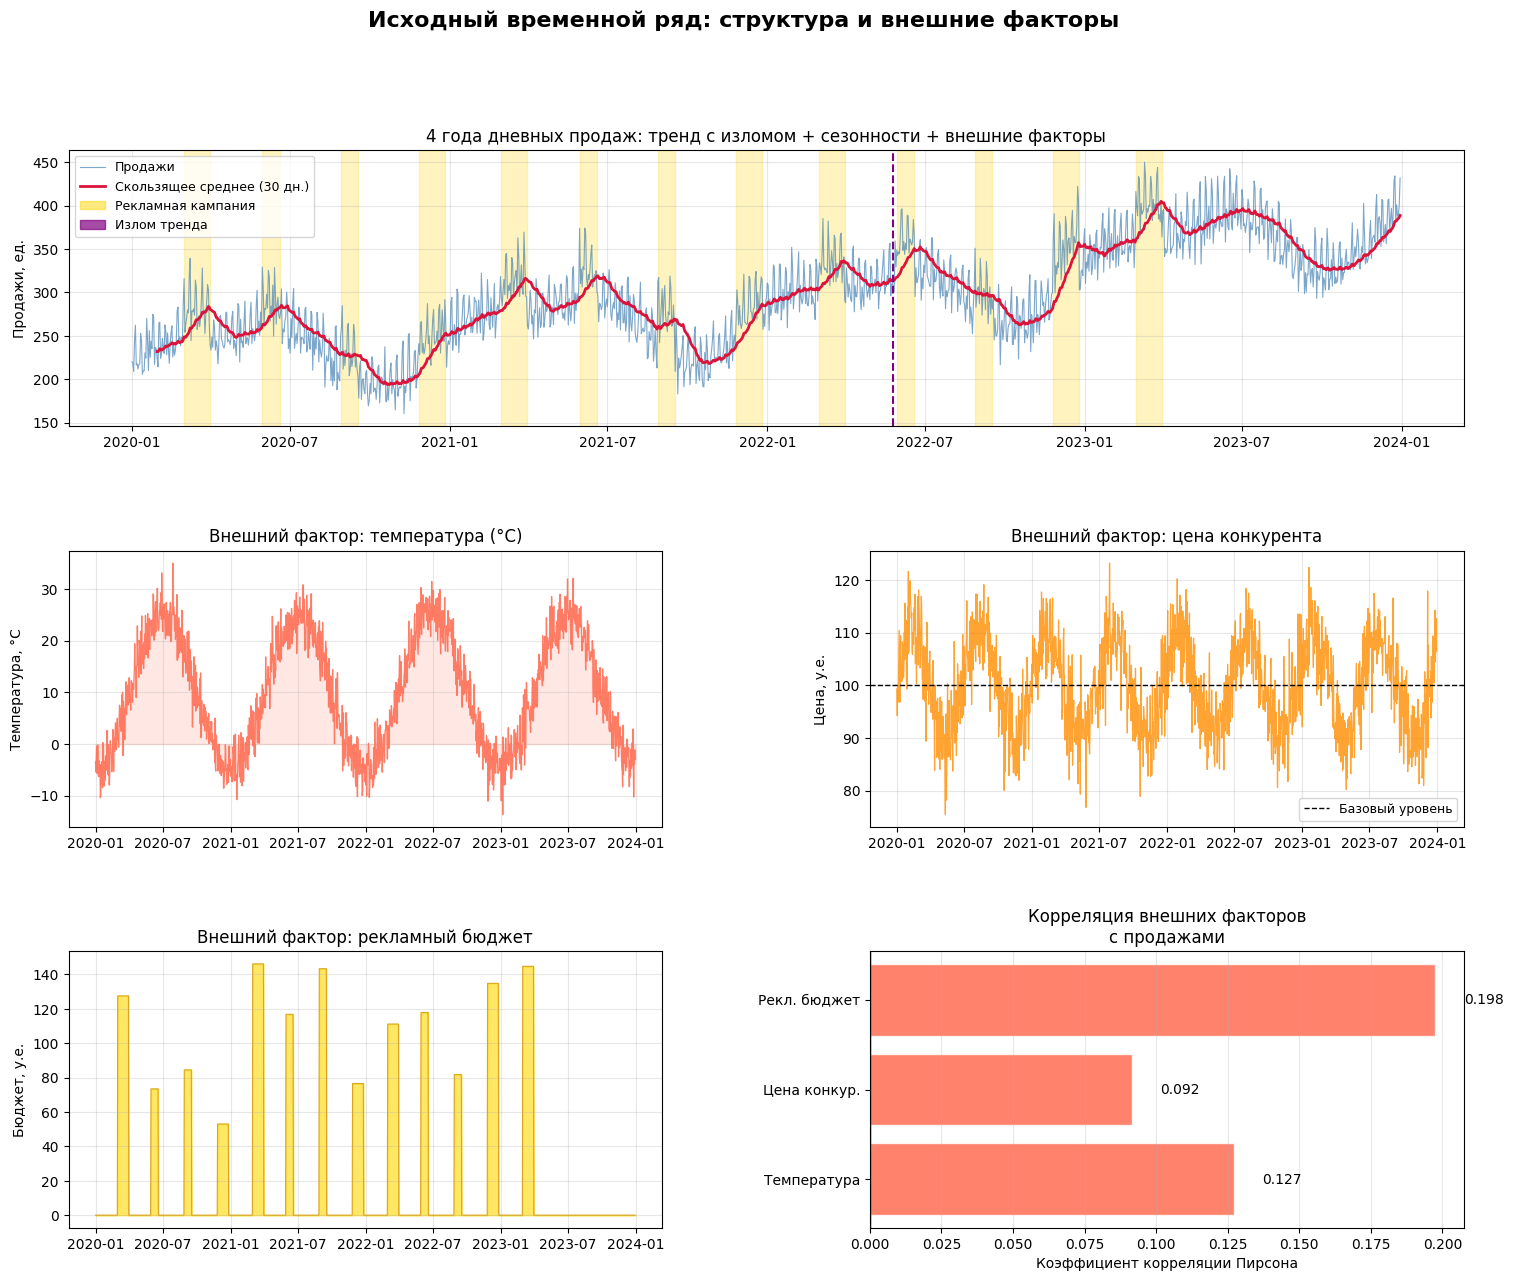

📅 Период: 2020-01-01 → 2023-12-30
📏 Длина:  1460 дней
📊 Среднее: 298.3  |  Std: 57.5


In [ ]:
##########################
# XGBOOST
##########################
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from xgboost import XGBRegressor, plot_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Воспроизводимость ──────────────────────────────────────────────────────────
np.random.seed(42)

# ── Параметры генерации ────────────────────────────────────────────────────────
N_PERIODS = 365 * 4     # 4 года дневных наблюдений
TEST_SIZE = 90          # последние 90 дней — тест

# ── Генерация дат ──────────────────────────────────────────────────────────────
dates = pd.date_range(start='2020-01-01', periods=N_PERIODS, freq='D')

# ── Компоненты ряда ────────────────────────────────────────────────────────────
t = np.arange(N_PERIODS)

# Нелинейный тренд с изломом (именно такой тренд сложен для XGBoost!)
trend = np.where(
    t < N_PERIODS * 0.6,
    200 + 0.08 * t,
    200 + 0.08 * (N_PERIODS * 0.6) + 0.18 * (t - N_PERIODS * 0.6)
)

# Годовая сезонность
day_of_year = np.arange(N_PERIODS) % 365
annual = (
    35 * np.sin(2 * np.pi * day_of_year / 365) +
    15 * np.cos(4 * np.pi * day_of_year / 365)  # вторая гармоника
)

# Недельная сезонность
day_of_week = pd.Series(dates).dt.dayofweek.values
weekly = np.where(day_of_week >= 5, 40, np.where(day_of_week == 0, -10, 5))

# Внешние факторы (то, ради чего XGBoost и выбирают!)
# Температура воздуха: влияет на продажи
temperature = (
    15 * np.sin(2 * np.pi * day_of_year / 365 - np.pi / 2) + 10 +
    np.random.normal(0, 3, N_PERIODS)
)
temp_effect = 0.8 * temperature   # +0.8 ед. продаж на каждый градус

# Цена конкурента: обратная зависимость
competitor_price = (
    100 + 10 * np.sin(2 * np.pi * t / 180) +
    np.random.normal(0, 5, N_PERIODS)
)
price_effect = 0.5 * (competitor_price - 100)  # если конкурент дороже — растём

# Рекламный бюджет (дискретные кампании)
ad_budget = np.zeros(N_PERIODS)
ad_periods = [
    (60,  90),  (150, 170), (240, 260), (330, 360),
    (425, 455), (515, 535), (605, 625), (695, 725),
    (790, 820), (880, 900), (970, 990), (1060, 1090),
    (1155, 1185),
]
for start, end in ad_periods:
    if end <= N_PERIODS:
        ad_budget[start:end] = np.random.uniform(50, 150)
ad_effect = 0.3 * ad_budget

# Шум
noise = np.random.normal(0, 10, N_PERIODS)

# ── Итоговый ряд ──────────────────────────────────────────────────────────────
values = trend + annual + weekly + temp_effect + price_effect + ad_effect + noise
values = np.clip(values, 0, None)

# ── Собираем DataFrame сразу с внешними факторами ─────────────────────────────
df_raw = pd.DataFrame({
    'date':             dates,
    'sales':            values,
    'temperature':      temperature,
    'competitor_price': competitor_price,
    'ad_budget':        ad_budget,
}).set_index('date')

# ══════════════════════════════════════════════════════════════════════════════
# Визуализация исходного ряда
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Исходный временной ряд: структура и внешние факторы',
             fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── График 1: полный ряд ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df_raw.index, df_raw['sales'],
         color='steelblue', linewidth=0.8, alpha=0.7, label='Продажи')
ax1.plot(df_raw['sales'].rolling(30).mean(),
         color='crimson', linewidth=2, label='Скользящее среднее (30 дн.)')

# Подсвечиваем рекламные кампании
for start, end in ad_periods:
    if end <= N_PERIODS:
        ax1.axvspan(dates[start], dates[min(end, N_PERIODS-1)],
                    color='gold', alpha=0.25)
gold_patch = mpatches.Patch(color='gold', alpha=0.5, label='Рекламная кампания')

# Граница тренда
breakpoint_date = dates[int(N_PERIODS * 0.6)]
ax1.axvline(breakpoint_date, color='purple', linewidth=1.5,
            linestyle='--', label='Излом тренда')
ax1.set_title('4 года дневных продаж: тренд с изломом + сезонности + внешние факторы')
ax1.set_ylabel('Продажи, ед.')
ax1.legend(handles=[*ax1.lines[:2],
                    gold_patch,
                    mpatches.Patch(color='purple', alpha=0.7,
                                   label='Излом тренда')],
           fontsize=9, loc='upper left')
ax1.grid(alpha=0.3)

# ── График 2: температура ─────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(df_raw.index, df_raw['temperature'],
         color='tomato', linewidth=0.9, alpha=0.8)
ax2.fill_between(df_raw.index, df_raw['temperature'],
                 color='tomato', alpha=0.15)
ax2.set_title('Внешний фактор: температура (°C)')
ax2.set_ylabel('Температура, °C')
ax2.grid(alpha=0.3)

# ── График 3: цена конкурента ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(df_raw.index, df_raw['competitor_price'],
         color='darkorange', linewidth=0.9, alpha=0.8)
ax3.axhline(100, color='black', linewidth=1,
            linestyle='--', label='Базовый уровень')
ax3.set_title('Внешний фактор: цена конкурента')
ax3.set_ylabel('Цена, у.е.')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# ── График 4: рекламный бюджет ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.fill_between(df_raw.index, df_raw['ad_budget'],
                 color='gold', alpha=0.6, label='Бюджет')
ax4.plot(df_raw.index, df_raw['ad_budget'],
         color='goldenrod', linewidth=0.8)
ax4.set_title('Внешний фактор: рекламный бюджет')
ax4.set_ylabel('Бюджет, у.е.')
ax4.grid(alpha=0.3)

# ── График 5: корреляция факторов с продажами ─────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
factors = {
    'Температура':    df_raw['temperature'].corr(df_raw['sales']),
    'Цена конкур.':   df_raw['competitor_price'].corr(df_raw['sales']),
    'Рекл. бюджет':   df_raw['ad_budget'].corr(df_raw['sales']),
}
colors_corr = ['tomato' if v > 0 else 'steelblue' for v in factors.values()]
bars = ax5.barh(list(factors.keys()), list(factors.values()),
                color=colors_corr, alpha=0.8, edgecolor='white')
ax5.axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, factors.values()):
    ax5.text(val + 0.01 if val > 0 else val - 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=10,
             ha='left' if val > 0 else 'right')
ax5.set_title('Корреляция внешних факторов\nс продажами')
ax5.set_xlabel('Коэффициент корреляции Пирсона')
ax5.grid(alpha=0.3, axis='x')

plt.savefig('x01_series_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📅 Период: {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print(f"📏 Длина:  {len(df_raw)} дней")
print(f"📊 Среднее: {df_raw['sales'].mean():.1f}  |  Std: {df_raw['sales'].std():.1f}")


Размер после дропа NaN: (1370, 78)
Потеряно строк: 90 (максимальный лаг = 90 дней)

📦 Всего признаков: 74

📋 Признаки по группам:
  Календарные     : 18 шт. → ['day_of_week', 'day_of_month', 'day_of_year', 'week_of_year']...
  Лаговые         : 18 шт. → ['lag_1', 'lag_2', 'lag_3', 'lag_7']...
  Скользящие      : 31 шт. → ['rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7']...
  Динамика        :  5 шт. → ['diff_1', 'diff_7', 'diff_30', 'lag1_vs_mean7']...
  Тренд           :  2 шт. → ['t', 't_squared']
  Событийные      :  7 шт. → ['is_weekend', 'is_month_start', 'is_month_end', 'is_new_year']...


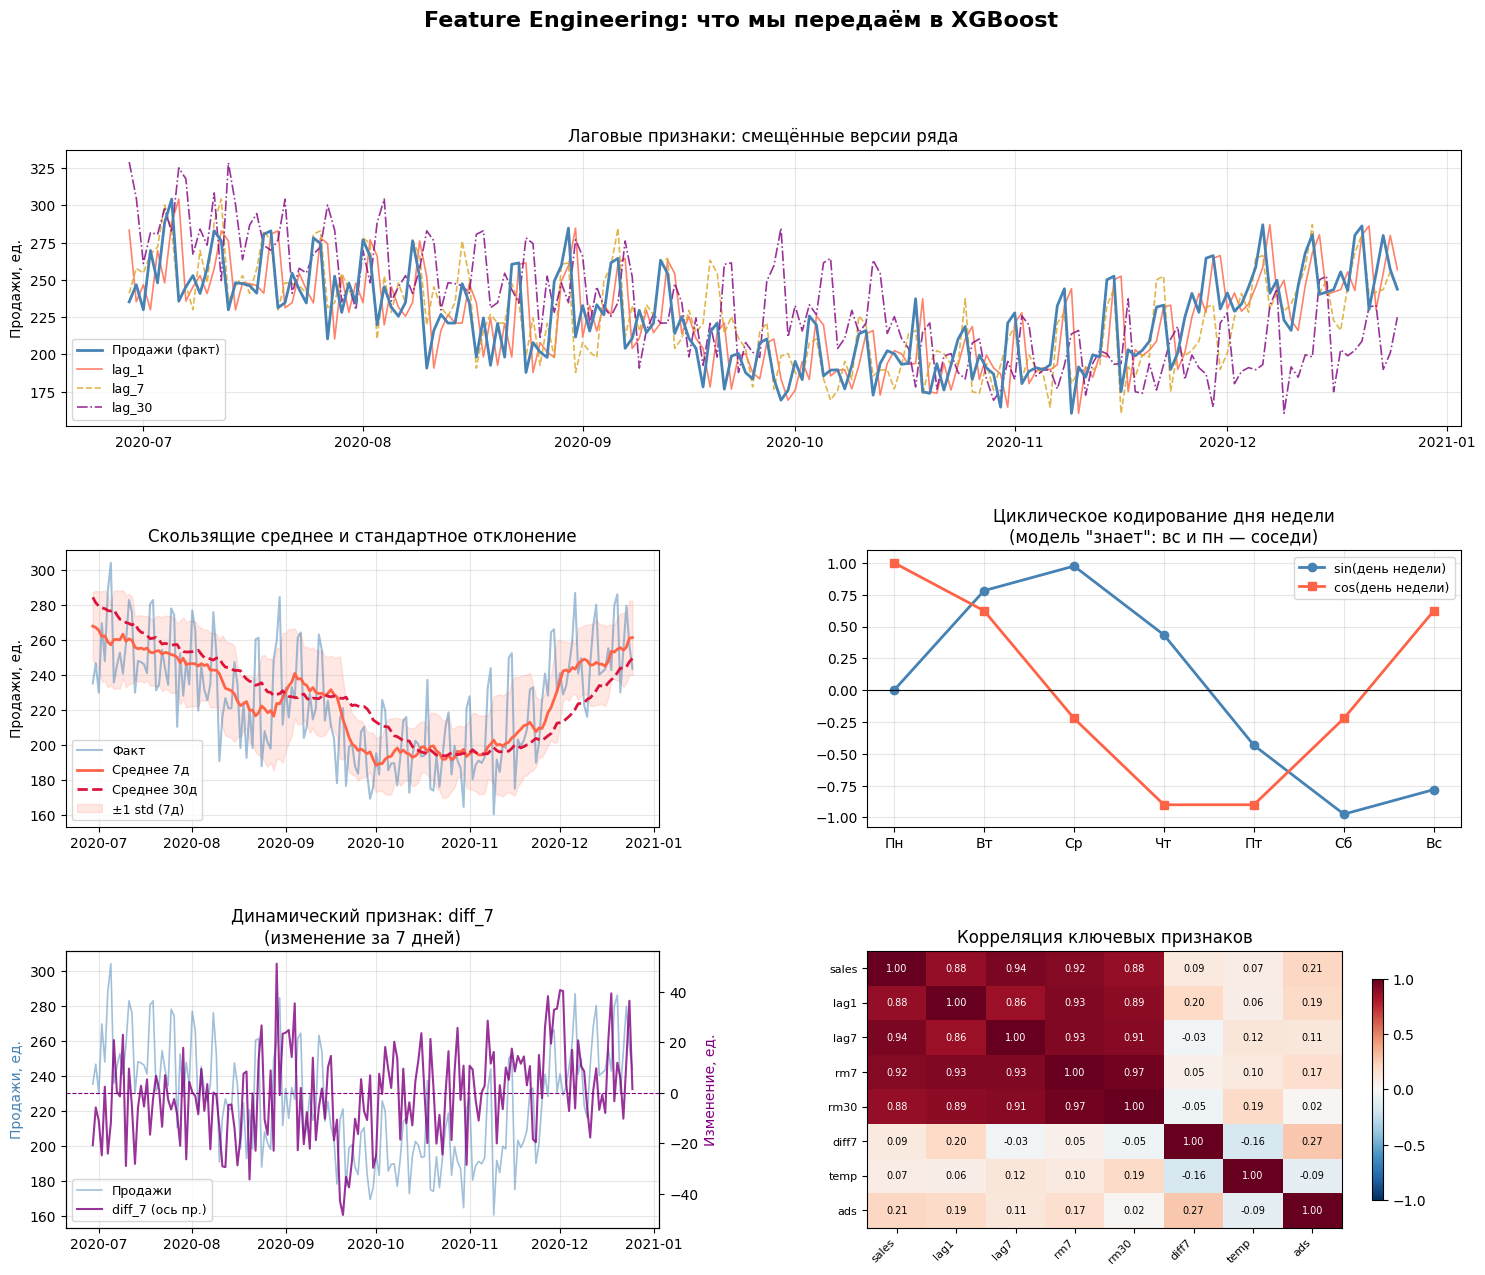

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Главная идея:
# XGBoost не "видит" время — мы сами кодируем все закономерности в фичи
# ══════════════════════════════════════════════════════════════════════════════

def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Полный пайплайн feature engineering для временного ряда.
    Возвращает DataFrame с признаками и целевой переменной.
    """
    d = df.copy()

    # ── Группа 1: календарные признаки ────────────────────────────────────
    # Кодируем «знание о времени», которое XGBoost не имеет нативно
    d['day_of_week']    = d.index.dayofweek          # 0=Пн, 6=Вс
    d['day_of_month']   = d.index.day
    d['day_of_year']    = d.index.dayofyear
    d['week_of_year']   = d.index.isocalendar().week.astype(int)
    d['month']          = d.index.month
    d['quarter']        = d.index.quarter
    d['year']           = d.index.year
    d['is_weekend']     = (d.index.dayofweek >= 5).astype(int)
    d['is_month_start'] = d.index.is_month_start.astype(int)
    d['is_month_end']   = d.index.is_month_end.astype(int)

    # Циклическое кодирование: день недели и месяц — цикличны!
    # sin/cos позволяет модели "знать", что пн рядом с вс, а дек рядом с янв
    d['dow_sin'] = np.sin(2 * np.pi * d['day_of_week'] / 7)
    d['dow_cos'] = np.cos(2 * np.pi * d['day_of_week'] / 7)
    d['month_sin'] = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month'] / 12)
    d['doy_sin'] = np.sin(2 * np.pi * d['day_of_year'] / 365)
    d['doy_cos'] = np.cos(2 * np.pi * d['day_of_year'] / 365)

    # ── Группа 2: лаговые признаки ────────────────────────────────────────
    # «Что было вчера, неделю назад, месяц назад?»
    lag_days = [1, 2, 3, 7, 14, 21, 28, 30, 60, 90]
    for lag in lag_days:
        d[f'lag_{lag}'] = d['sales'].shift(lag)

    # Лаги внешних факторов
    for col in ['temperature', 'competitor_price', 'ad_budget']:
        d[f'{col}_lag1'] = d[col].shift(1)
        d[f'{col}_lag7'] = d[col].shift(7)

    # ── Группа 3: скользящие статистики ───────────────────────────────────
    # «Какова была средняя/волатильность за последние N дней?»
    windows = [7, 14, 30, 60, 90]
    for w in windows:
        rolled = d['sales'].shift(1).rolling(window=w)
        d[f'rolling_mean_{w}']   = rolled.mean()
        d[f'rolling_std_{w}']    = rolled.std()
        d[f'rolling_min_{w}']    = rolled.min()
        d[f'rolling_max_{w}']    = rolled.max()
        d[f'rolling_median_{w}'] = rolled.median()

    # Скользящие по внешним факторам
    for col in ['temperature', 'ad_budget']:
        d[f'{col}_rolling7']  = d[col].shift(1).rolling(7).mean()
        d[f'{col}_rolling30'] = d[col].shift(1).rolling(30).mean()

    # ── Группа 4: признаки динамики (скорость изменения) ──────────────────
    d['diff_1']  = d['sales'].shift(1).diff(1)   # изменение за 1 день
    d['diff_7']  = d['sales'].shift(1).diff(7)   # изменение за неделю
    d['diff_30'] = d['sales'].shift(1).diff(30)  # изменение за месяц

    # Отношение текущего лага к скользящему: «выше или ниже нормы?»
    d['lag1_vs_mean7']  = d['lag_1'] / (d['rolling_mean_7']  + 1e-6)
    d['lag1_vs_mean30'] = d['lag_1'] / (d['rolling_mean_30'] + 1e-6)

    # Экспоненциально взвешенное скользящее среднее (свежие данные важнее)
    d['ewm_7']  = d['sales'].shift(1).ewm(span=7,  adjust=False).mean()
    d['ewm_30'] = d['sales'].shift(1).ewm(span=30, adjust=False).mean()

    # ── Группа 5: признаки тренда ─────────────────────────────────────────
    # Порядковый номер дня — XGBoost не умеет экстраполировать,
    # поэтому явно кодируем позицию во времени
    d['t'] = np.arange(len(d))
    d['t_squared'] = d['t'] ** 2   # нелинейный тренд

    # ── Группа 6: событийные признаки ─────────────────────────────────────
    # Флаги праздников / акций вместо таблицы holidays как в Prophet
    d['is_new_year']  = (
        (d.index.month == 1) & (d.index.day <= 8)
    ).astype(int)
    d['is_black_friday'] = 0
    bf_dates = pd.to_datetime(['2020-11-27', '2021-11-26',
                               '2022-11-25', '2023-11-24'])
    for bf in bf_dates:
        mask = (d.index >= bf - pd.Timedelta(days=2)) & \
               (d.index <= bf + pd.Timedelta(days=1))
        d.loc[mask, 'is_black_friday'] = 1

    d['is_march_8'] = (
        (d.index.month == 3) & (d.index.day == 8)
    ).astype(int)

    d['has_ad_campaign'] = (d['ad_budget'] > 0).astype(int)

    return d


# ── Строим признаки ───────────────────────────────────────────────────────────
df_features = build_features(df_raw)

# Удаляем строки с NaN (появились из-за лагов и скользящих окон)
df_features = df_features.dropna()

print(f"Размер после дропа NaN: {df_features.shape}")
print(f"Потеряно строк: {len(df_raw) - len(df_features)} "
      f"(максимальный лаг = 90 дней)")

# ── Список признаков ──────────────────────────────────────────────────────────
TARGET   = 'sales'
DROP_COLS = [TARGET, 'temperature', 'competitor_price', 'ad_budget']
FEATURES  = [c for c in df_features.columns if c not in DROP_COLS]

print(f"\n📦 Всего признаков: {len(FEATURES)}")

# Группировка признаков для отчёта
feature_groups = {
    'Календарные':      [f for f in FEATURES if any(k in f for k in
                         ['day', 'week', 'month', 'quarter', 'year',
                          'weekend', 'sin', 'cos'])],
    'Лаговые':          [f for f in FEATURES if 'lag' in f],
    'Скользящие':       [f for f in FEATURES if 'rolling' in f or 'ewm' in f],
    'Динамика':         [f for f in FEATURES if 'diff' in f or 'vs_mean' in f],
    'Тренд':            [f for f in FEATURES if f in ['t', 't_squared']],
    'Событийные':       [f for f in FEATURES if 'is_' in f or 'has_' in f],
}
print("\n📋 Признаки по группам:")
for group, feats in feature_groups.items():
    print(f"  {group:<16}: {len(feats):>2} шт. → {feats[:4]}{'...' if len(feats)>4 else ''}")

# ══════════════════════════════════════════════════════════════════════════════
# Визуализация Feature Engineering
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Feature Engineering: что мы передаём в XGBoost',
             fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

sample = df_features.iloc[90:270]   # полгода для наглядности

# ── График 1: лаги ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(sample.index, sample['sales'],
         color='steelblue', linewidth=2, label='Продажи (факт)', zorder=5)
for lag, color, ls in [(1, 'tomato', '-'),
                        (7, 'goldenrod', '--'),
                        (30, 'purple', '-.')]:
    ax1.plot(sample.index, sample[f'lag_{lag}'],
             color=color, linewidth=1.2, linestyle=ls, alpha=0.8,
             label=f'lag_{lag}')
ax1.set_title('Лаговые признаки: смещённые версии ряда')
ax1.set_ylabel('Продажи, ед.')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── График 2: скользящие статистики ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(sample.index, sample['sales'],
         color='steelblue', linewidth=1.5, alpha=0.5, label='Факт')
ax2.plot(sample.index, sample['rolling_mean_7'],
         color='tomato', linewidth=2, label='Среднее 7д')
ax2.plot(sample.index, sample['rolling_mean_30'],
         color='crimson', linewidth=2, linestyle='--', label='Среднее 30д')
ax2.fill_between(sample.index,
                 sample['rolling_mean_7'] - sample['rolling_std_7'],
                 sample['rolling_mean_7'] + sample['rolling_std_7'],
                 color='tomato', alpha=0.15, label='±1 std (7д)')
ax2.set_title('Скользящие среднее и стандартное отклонение')
ax2.set_ylabel('Продажи, ед.')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# ── График 3: циклическое кодирование ────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
week_sample = pd.DataFrame({
    'day': range(7),
    'sin': [np.sin(2 * np.pi * d / 7) for d in range(7)],
    'cos': [np.cos(2 * np.pi * d / 7) for d in range(7)],
})
day_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
ax3.plot(week_sample['day'], week_sample['sin'],
         color='steelblue', marker='o', linewidth=2, label='sin(день недели)')
ax3.plot(week_sample['day'], week_sample['cos'],
         color='tomato', marker='s', linewidth=2, label='cos(день недели)')
ax3.set_xticks(range(7))
ax3.set_xticklabels(day_labels)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_title('Циклическое кодирование дня недели\n'
              '(модель "знает": вс и пн — соседи)')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# ── График 4: динамические признаки ──────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4_twin = ax4.twinx()
ax4.plot(sample.index, sample['sales'],
         color='steelblue', linewidth=1.2, alpha=0.5, label='Продажи')
ax4_twin.plot(sample.index, sample['diff_7'],
              color='purple', linewidth=1.5, alpha=0.8, label='diff_7 (ось пр.)')
ax4_twin.axhline(0, color='purple', linewidth=0.8, linestyle='--')
ax4.set_title('Динамический признак: diff_7\n(изменение за 7 дней)')
ax4.set_ylabel('Продажи, ед.', color='steelblue')
ax4_twin.set_ylabel('Изменение, ед.', color='purple')
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax4.grid(alpha=0.3)

# ── График 5: корреляционная матрица ключевых фичей ──────────────────────
ax5 = fig.add_subplot(gs[2, 1])
key_features = ['sales', 'lag_1', 'lag_7', 'rolling_mean_7',
                'rolling_mean_30', 'diff_7', 'temperature', 'ad_budget']
corr_matrix = df_features[key_features].corr()
im = ax5.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax5.set_xticks(range(len(key_features)))
ax5.set_yticks(range(len(key_features)))
short_names = ['sales', 'lag1', 'lag7', 'rm7', 'rm30', 'diff7', 'temp', 'ads']
ax5.set_xticklabels(short_names, rotation=45, ha='right', fontsize=8)
ax5.set_yticklabels(short_names, fontsize=8)
for i in range(len(key_features)):
    for j in range(len(key_features)):
        val = corr_matrix.iloc[i, j]
        ax5.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=7, color='white' if abs(val) > 0.6 else 'black')
plt.colorbar(im, ax=ax5, shrink=0.8)
ax5.set_title('Корреляция ключевых признаков')

plt.savefig('x02_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()


Train: 1280 строк  (2020-03-31 → 2023-10-01)
Test:  90 строк  (2023-10-02 → 2023-12-30)

✅ Early stopping: лучшая итерация = 67


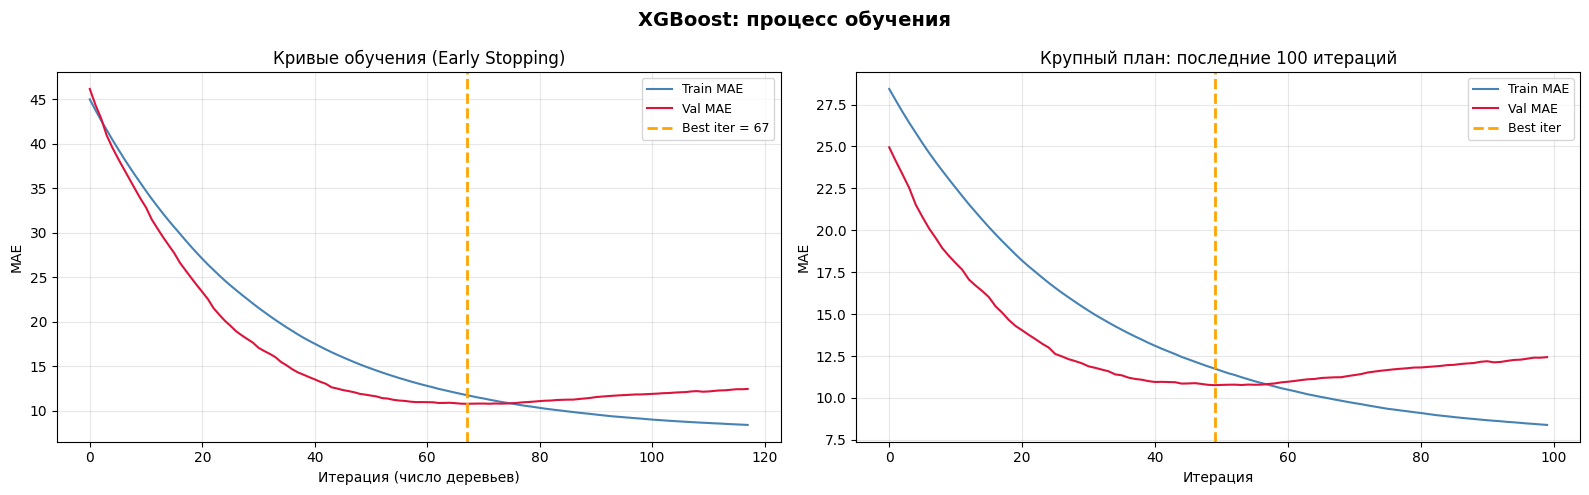

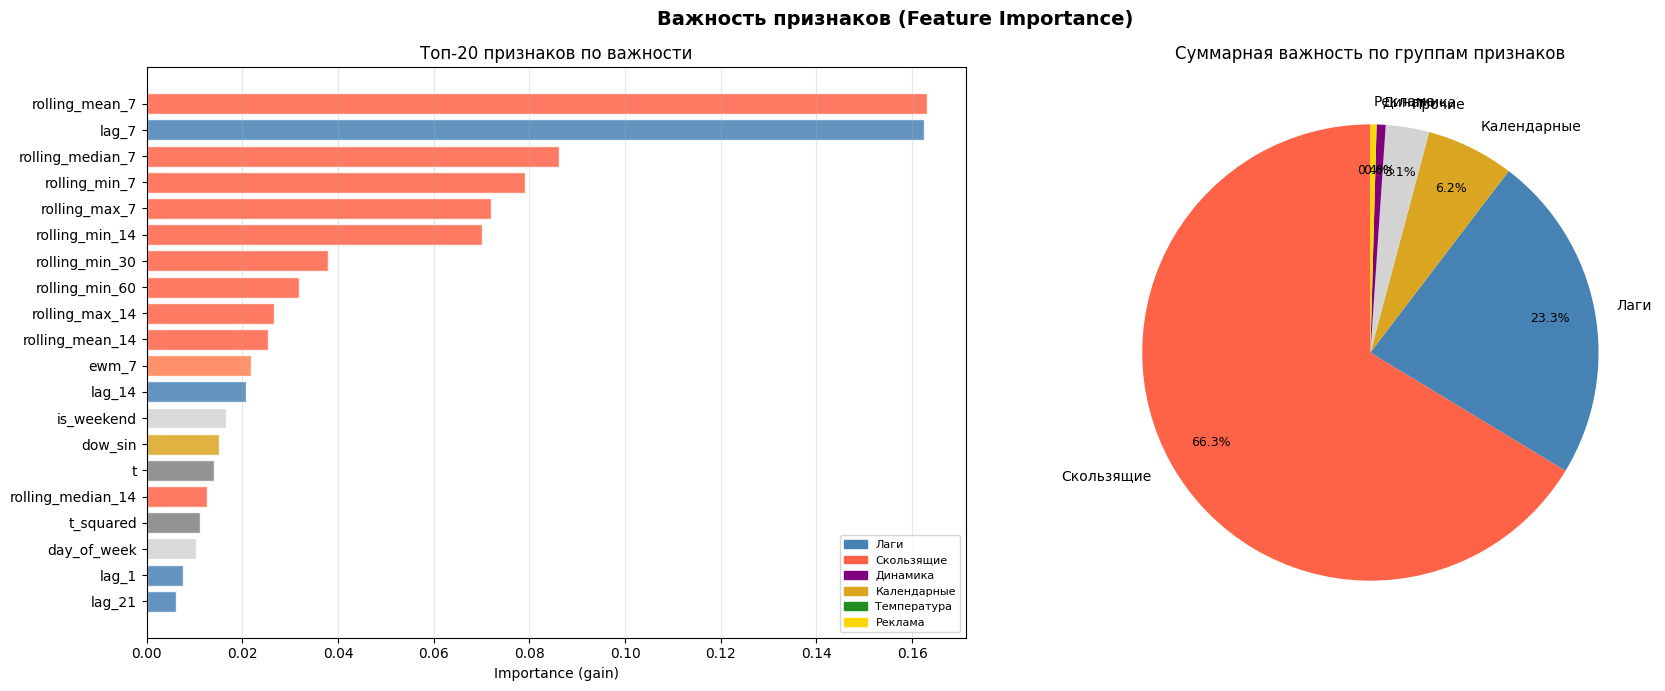

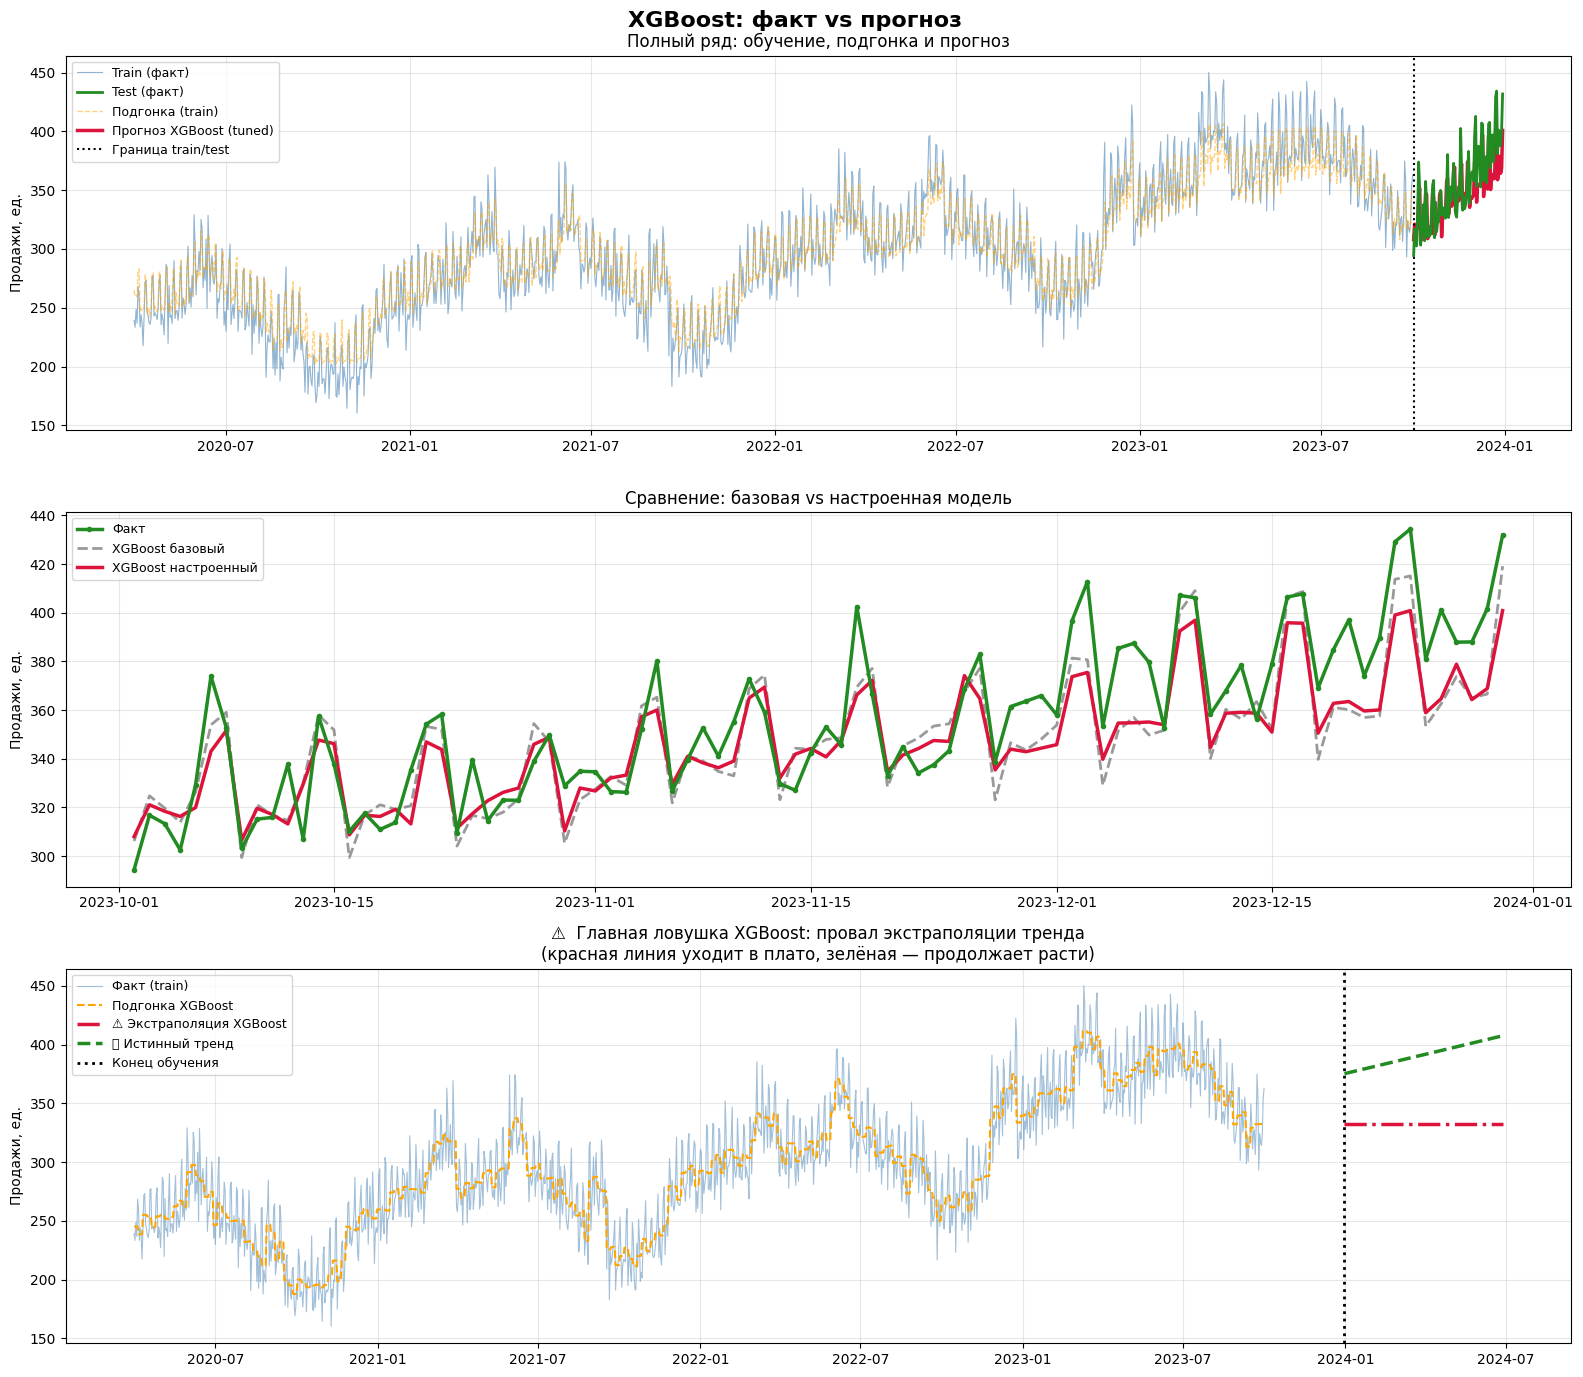

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Train / Test split
# ══════════════════════════════════════════════════════════════════════════════

split_idx  = len(df_features) - TEST_SIZE
train_data = df_features.iloc[:split_idx]
test_data  = df_features.iloc[split_idx:]

X_train = train_data[FEATURES]
y_train = train_data[TARGET]
X_test  = test_data[FEATURES]
y_test  = test_data[TARGET]

print(f"Train: {len(X_train)} строк  ({X_train.index[0].date()} → "
      f"{X_train.index[-1].date()})")
print(f"Test:  {len(X_test)} строк  ({X_test.index[0].date()} → "
      f"{X_test.index[-1].date()})")

# ══════════════════════════════════════════════════════════════════════════════
# Модель 1: базовая (без подбора гиперпараметров)
# ══════════════════════════════════════════════════════════════════════════════

model_base = XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
)
model_base.fit(X_train, y_train)
pred_base = model_base.predict(X_test)

# ══════════════════════════════════════════════════════════════════════════════
# Модель 2: с ранней остановкой (early stopping)
# ══════════════════════════════════════════════════════════════════════════════

# Выделяем валидационную выборку из обучающей
VAL_SIZE   = 60
X_tr  = X_train.iloc[:-VAL_SIZE]
y_tr  = y_train.iloc[:-VAL_SIZE]
X_val = X_train.iloc[-VAL_SIZE:]
y_val = y_train.iloc[-VAL_SIZE:]

model_tuned = XGBRegressor(
    n_estimators        = 2000,      # много деревьев — early stopping остановит
    learning_rate       = 0.03,      # меньше lr → лучше обобщение
    max_depth           = 4,         # меньше глубина → меньше переобучение
    min_child_weight    = 5,         # минимум объектов в листе
    subsample           = 0.75,
    colsample_bytree    = 0.75,
    colsample_bylevel   = 0.75,
    gamma               = 0.1,       # регуляризация сложности дерева
    reg_alpha           = 0.1,       # L1-регуляризация
    reg_lambda          = 1.0,       # L2-регуляризация
    random_state        = 42,
    n_jobs              = -1,
    early_stopping_rounds = 50,
    eval_metric         = 'mae',
)
model_tuned.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False,
)
pred_tuned = model_tuned.predict(X_test)

best_iter = model_tuned.best_iteration
print(f"\n✅ Early stopping: лучшая итерация = {best_iter}")

# ══════════════════════════════════════════════════════════════════════════════
# Кривые обучения (learning curves)
# ══════════════════════════════════════════════════════════════════════════════

evals_result = model_tuned.evals_result()
train_mae = evals_result['validation_0']['mae']
val_mae   = evals_result['validation_1']['mae']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('XGBoost: процесс обучения', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(train_mae, color='steelblue', linewidth=1.5, label='Train MAE')
ax.plot(val_mae,   color='crimson',   linewidth=1.5, label='Val MAE')
ax.axvline(best_iter, color='orange', linewidth=2,
           linestyle='--', label=f'Best iter = {best_iter}')
ax.set_title('Кривые обучения (Early Stopping)')
ax.set_xlabel('Итерация (число деревьев)')
ax.set_ylabel('MAE')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Крупный план: финальные итерации
window = 100
ax = axes[1]
ax.plot(train_mae[-window:], color='steelblue', linewidth=1.5, label='Train MAE')
ax.plot(val_mae[-window:],   color='crimson',   linewidth=1.5, label='Val MAE')
ax.axvline(best_iter - (len(train_mae) - window),
           color='orange', linewidth=2, linestyle='--',
           label=f'Best iter')
ax.set_title(f'Крупный план: последние {window} итераций')
ax.set_xlabel('Итерация')
ax.set_ylabel('MAE')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('x03a_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Feature Importance
# ══════════════════════════════════════════════════════════════════════════════

importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': model_tuned.feature_importances_,
}).sort_values('importance', ascending=False)

TOP_N = 20

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Важность признаков (Feature Importance)',
             fontsize=14, fontweight='bold')

# ── Горизонтальный бар-чарт топ-N ────────────────────────────────────────
ax = axes[0]
top = importance_df.head(TOP_N)
colors_fi = []
group_color_map = {
    'lag':      'steelblue',
    'rolling':  'tomato',
    'ewm':      'coral',
    'diff':     'purple',
    'dow':      'goldenrod',
    'month':    'goldenrod',
    'doy':      'goldenrod',
    'temp':     'forestgreen',
    'ad':       'gold',
    'compet':   'darkorange',
    't':        'gray',
}
for feat in top['feature']:
    color = 'lightgray'
    for key, col in group_color_map.items():
        if key in feat:
            color = col
            break
    colors_fi.append(color)

bars = ax.barh(top['feature'][::-1], top['importance'][::-1],
               color=colors_fi[::-1], edgecolor='white', alpha=0.85)
ax.set_title(f'Топ-{TOP_N} признаков по важности')
ax.set_xlabel('Importance (gain)')
ax.grid(alpha=0.3, axis='x')

# Легенда групп
legend_items = [
    mpatches.Patch(color='steelblue',   label='Лаги'),
    mpatches.Patch(color='tomato',      label='Скользящие'),
    mpatches.Patch(color='purple',      label='Динамика'),
    mpatches.Patch(color='goldenrod',   label='Календарные'),
    mpatches.Patch(color='forestgreen', label='Температура'),
    mpatches.Patch(color='gold',        label='Реклама'),
]
ax.legend(handles=legend_items, fontsize=8, loc='lower right')

# ── Важность по группам (суммарная) ──────────────────────────────────────
ax = axes[1]
group_importance = {}
for feat, imp in zip(importance_df['feature'], importance_df['importance']):
    assigned = 'Прочие'
    for key in ['lag', 'rolling', 'ewm', 'diff', 'dow', 'month', 'doy',
                'temperature', 'ad', 'competitor', 't']:
        if key in feat:
            if key in ['lag']:               assigned = 'Лаги'
            elif key in ['rolling', 'ewm']:  assigned = 'Скользящие'
            elif key in ['diff']:            assigned = 'Динамика'
            elif key in ['dow', 'month', 'doy', 't']: assigned = 'Календарные'
            elif key in ['temperature']:     assigned = 'Температура'
            elif key in ['ad']:              assigned = 'Реклама'
            elif key in ['competitor']:      assigned = 'Цена конкур.'
            break
    group_importance[assigned] = group_importance.get(assigned, 0) + imp

gi_df = pd.DataFrame(group_importance.items(),
                      columns=['group', 'importance']
                      ).sort_values('importance', ascending=False)
group_colors = {
    'Лаги':         'steelblue',
    'Скользящие':   'tomato',
    'Динамика':     'purple',
    'Календарные':  'goldenrod',
    'Температура':  'forestgreen',
    'Реклама':      'gold',
    'Цена конкур.': 'darkorange',
    'Прочие':       'lightgray',
}
wedge_colors = [group_colors.get(g, 'lightgray') for g in gi_df['group']]
wedges, texts, autotexts = ax.pie(
    gi_df['importance'],
    labels=gi_df['group'],
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
)
for text in autotexts:
    text.set_fontsize(9)
ax.set_title('Суммарная важность по группам признаков')

plt.tight_layout()
plt.savefig('x03b_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Визуализация прогноза
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('XGBoost: факт vs прогноз', fontsize=16, fontweight='bold')

# ── График 1: полный ряд ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(train_data.index, y_train,
        color='steelblue', linewidth=0.8, alpha=0.6, label='Train (факт)')
ax.plot(test_data.index, y_test,
        color='forestgreen', linewidth=2, label='Test (факт)', zorder=5)
ax.plot(train_data.index, model_tuned.predict(X_train),
        color='orange', linewidth=1, alpha=0.5, linestyle='--',
        label='Подгонка (train)')
ax.plot(test_data.index, pred_tuned,
        color='crimson', linewidth=2.5, label='Прогноз XGBoost (tuned)')
ax.axvline(test_data.index[0], color='black', linewidth=1.5,
           linestyle=':', label='Граница train/test')
ax.set_title('Полный ряд: обучение, подгонка и прогноз')
ax.set_ylabel('Продажи, ед.')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)

# ── График 2: сравнение базовой и настроенной модели на тесте ─────────────
ax = axes[1]
ax.plot(test_data.index, y_test,
        color='forestgreen', linewidth=2.5, marker='o',
        markersize=3, label='Факт', zorder=5)
ax.plot(test_data.index, pred_base,
        color='gray', linewidth=2, linestyle='--', alpha=0.8,
        label='XGBoost базовый')
ax.plot(test_data.index, pred_tuned,
        color='crimson', linewidth=2.5, label='XGBoost настроенный')
ax.set_title('Сравнение: базовая vs настроенная модель')
ax.set_ylabel('Продажи, ед.')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── График 3: демонстрация проблемы экстраполяции (важно!) ───
ax = axes[2]

# Обучаем упрощённую модель ТОЛЬКО на тренде — покажем проблему XGBoost
model_trend_demo = XGBRegressor(
    n_estimators=300, max_depth=3, random_state=42
)
X_trend = train_data[['t', 't_squared']].values
model_trend_demo.fit(X_trend, y_train)

# Прогноз на 180 дней вперёд от конца данных
future_t = np.arange(len(df_features),
                      len(df_features) + 180).reshape(-1, 1)
future_t_sq = future_t ** 2
future_preds = model_trend_demo.predict(
    np.hstack([future_t, future_t_sq])
)
last_train_pred = model_trend_demo.predict(X_trend)

ax.plot(train_data.index, y_train,
        color='steelblue', linewidth=0.8, alpha=0.5, label='Факт (train)')
ax.plot(train_data.index, last_train_pred,
        color='orange', linewidth=1.5, linestyle='--',
        label='Подгонка XGBoost')
future_dates = pd.date_range(
    start=df_features.index[-1] + pd.Timedelta(days=1),
    periods=180, freq='D'
)
ax.plot(future_dates, future_preds,
        color='crimson', linewidth=2.5, linestyle='-.',
        label='⚠️ Экстраполяция XGBoost')

# Что должно быть по истинному тренду
true_future_t = np.arange(len(df_raw),
                            len(df_raw) + 180)
true_trend = 200 + 0.08 * (N_PERIODS * 0.6) + 0.18 * (true_future_t - N_PERIODS * 0.6)
ax.plot(future_dates, true_trend,
        color='forestgreen', linewidth=2.5, linestyle='--',
        label='✅ Истинный тренд')
ax.axvline(df_features.index[-1], color='black', linewidth=2,
           linestyle=':', label='Конец обучения')
ax.set_title('⚠️  Главная ловушка XGBoost: провал экстраполяции тренда\n'
             '(красная линия уходит в плато, зелёная — продолжает расти)')
ax.set_ylabel('Продажи, ед.')
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('x03c_forecast.png', dpi=150, bbox_inches='tight')
plt.show()



📊 Метрики: XGBoost базовый
  MAE  = 13.01
  RMSE = 16.53
  MAPE = 3.58%
  Bias = 7.65
  R²   = 0.7393

📊 Метрики: XGBoost настроенный
  MAE  = 13.43
  RMSE = 16.94
  MAPE = 3.64%
  Bias = 8.85
  R²   = 0.7262


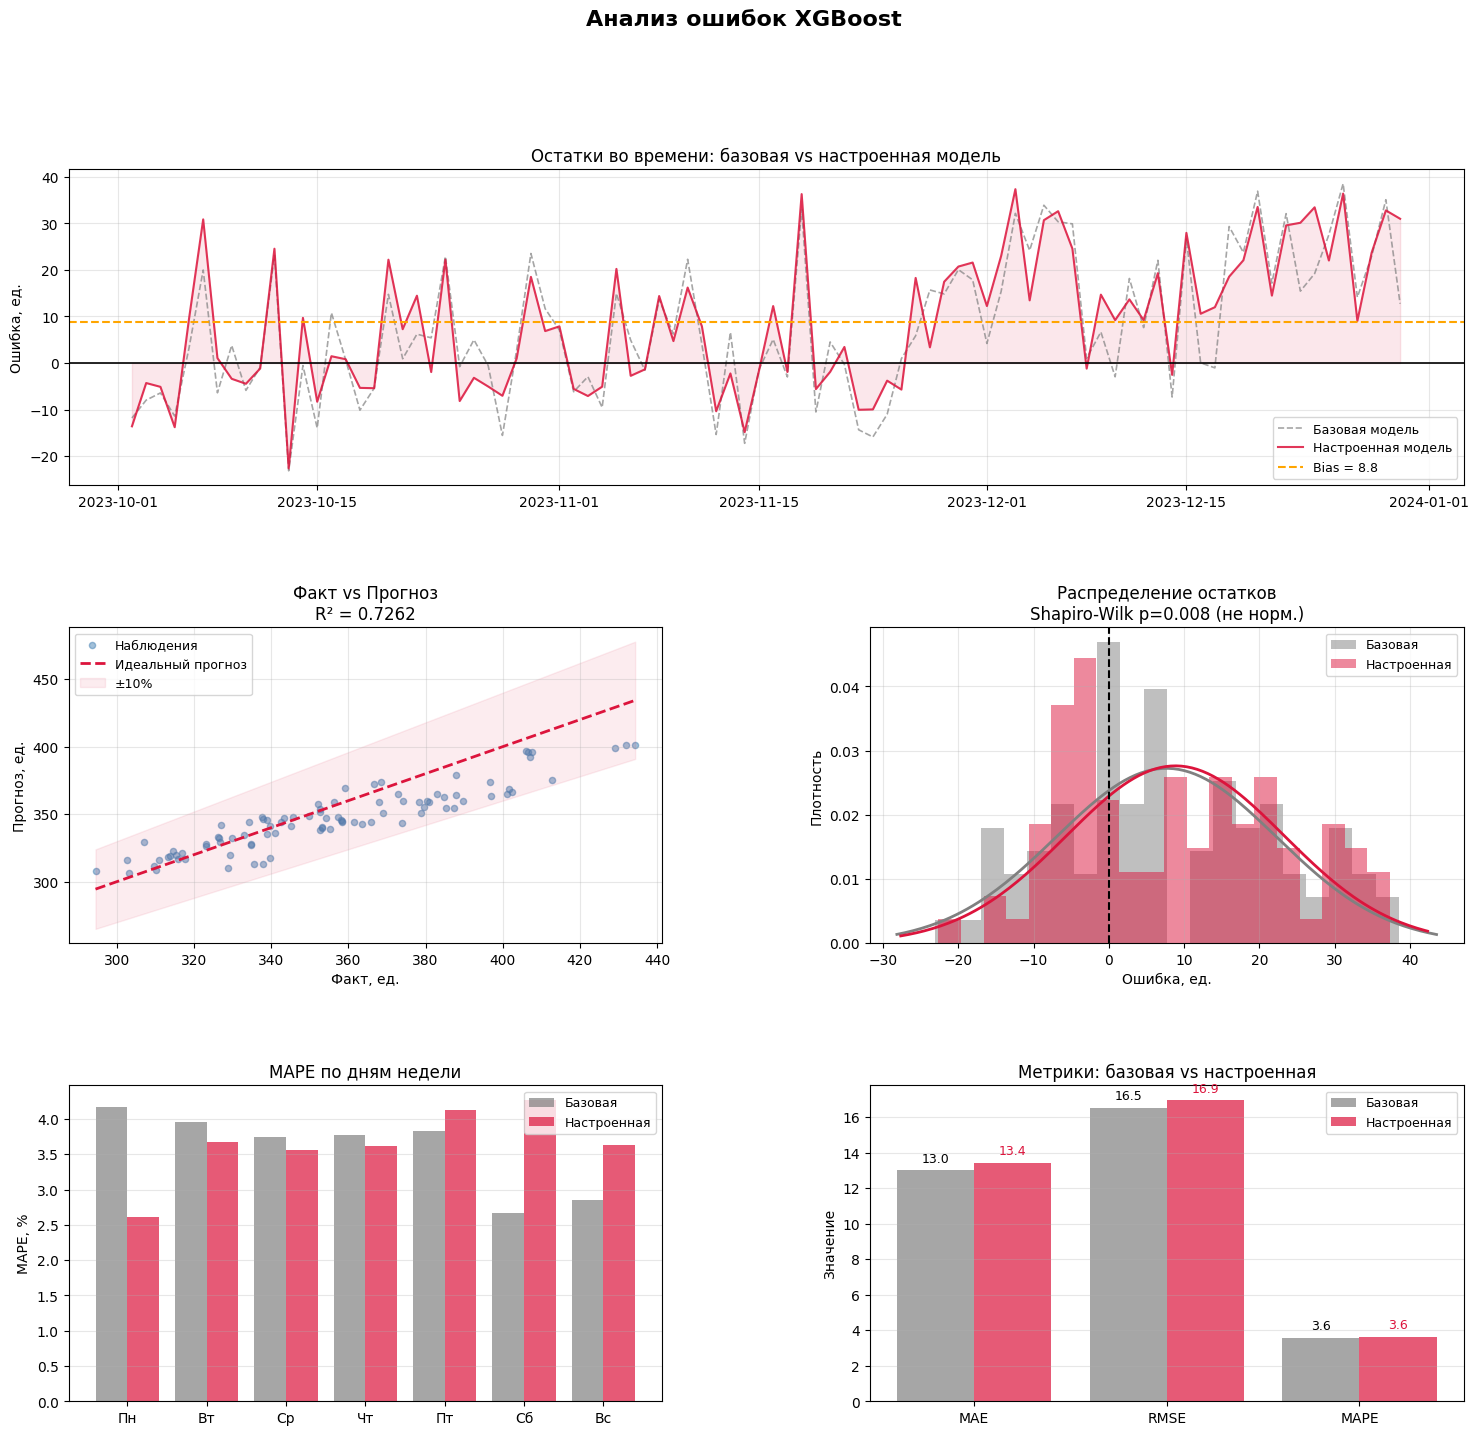

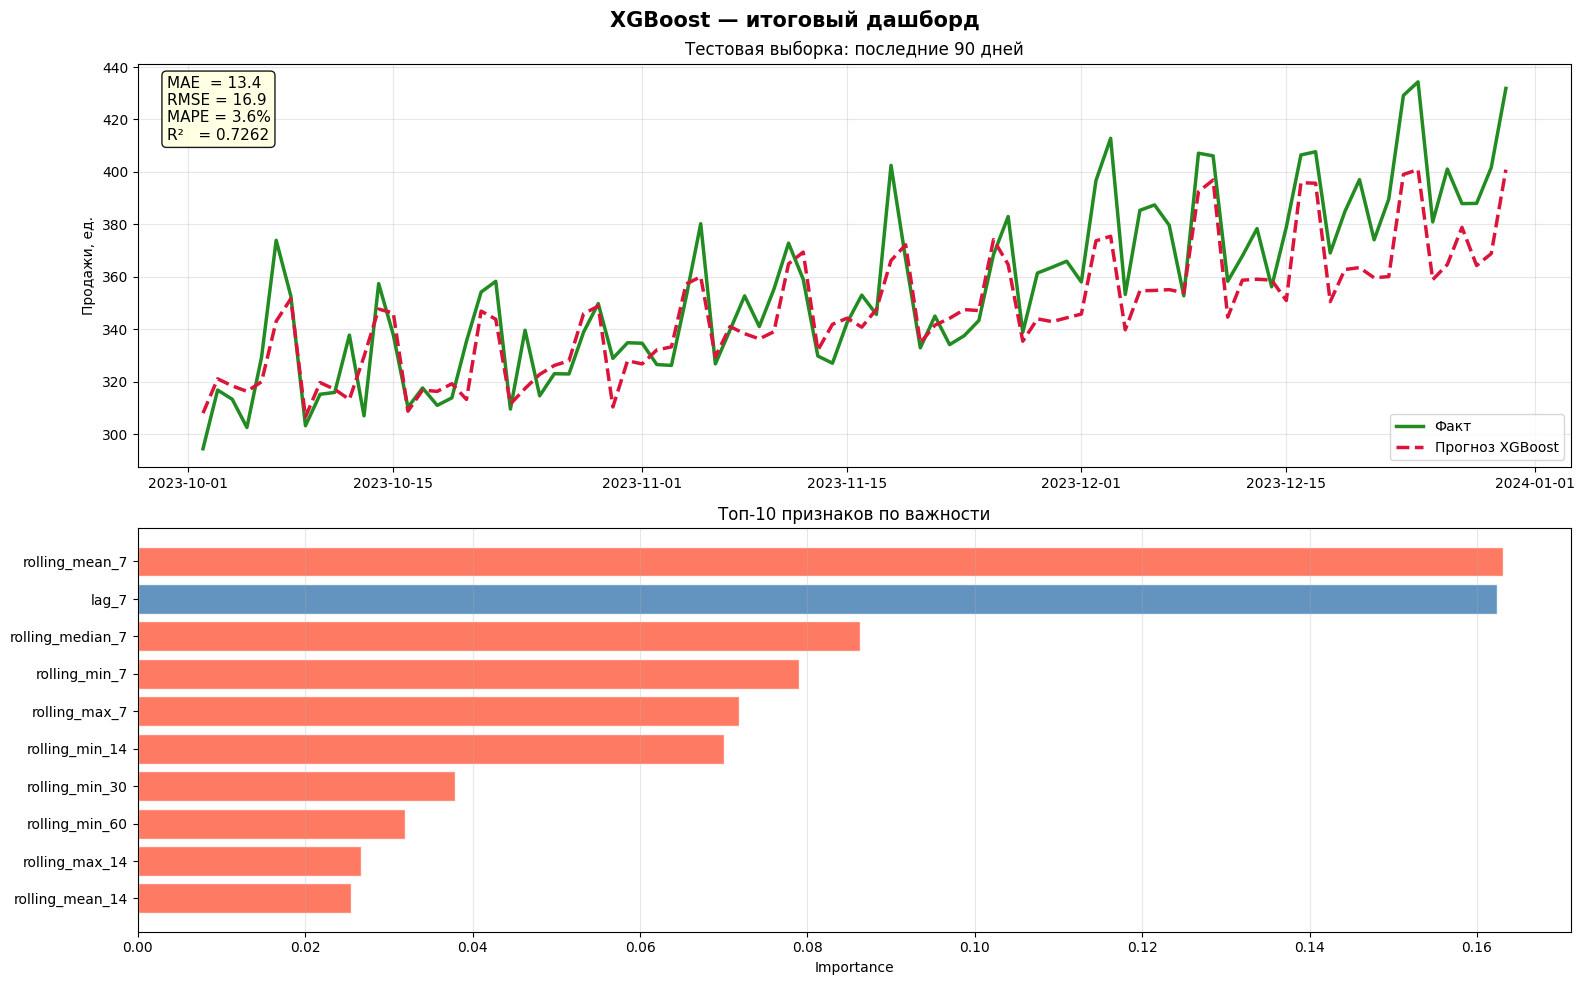

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Метрики
# ══════════════════════════════════════════════════════════════════════════════

def metrics_report(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    bias = np.mean(y_true - y_pred)
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    print(f"\n📊 Метрики: {label}")
    print(f"  MAE  = {mae:.2f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  Bias = {bias:.2f}")
    print(f"  R²   = {r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'Bias': bias, 'R2': r2}

m_base  = metrics_report(y_test.values, pred_base,  'XGBoost базовый')
m_tuned = metrics_report(y_test.values, pred_tuned, 'XGBoost настроенный')

errors_base  = y_test.values - pred_base
errors_tuned = y_test.values - pred_tuned
errors_pct   = np.abs(errors_tuned / y_test.values) * 100

# ══════════════════════════════════════════════════════════════════════════════
# Визуализация ошибок — 6 графиков
# ══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 16))
fig.suptitle('Анализ ошибок XGBoost', fontsize=16, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── График 1: остатки обеих моделей во времени ────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_data.index, errors_base,
         color='gray', linewidth=1.2, alpha=0.7, linestyle='--',
         label='Базовая модель')
ax1.plot(test_data.index, errors_tuned,
         color='crimson', linewidth=1.5, alpha=0.85,
         label='Настроенная модель')
ax1.fill_between(test_data.index, errors_tuned, 0,
                 color='crimson', alpha=0.1)
ax1.axhline(0, color='black', linewidth=1.2)
ax1.axhline(errors_tuned.mean(), color='orange', linewidth=1.5,
            linestyle='--', label=f'Bias = {errors_tuned.mean():.1f}')
ax1.set_title('Остатки во времени: базовая vs настроенная модель')
ax1.set_ylabel('Ошибка, ед.')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── График 2: Actual vs Predicted (scatter) ───────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(y_test, pred_tuned,
            color='steelblue', alpha=0.5, s=20, label='Наблюдения')
min_val = min(y_test.min(), pred_tuned.min())
max_val = max(y_test.max(), pred_tuned.max())
ax2.plot([min_val, max_val], [min_val, max_val],
         color='crimson', linewidth=2, linestyle='--', label='Идеальный прогноз')
# Полоса ±10%
ax2.fill_between([min_val, max_val],
                 [min_val * 0.9, max_val * 0.9],
                 [min_val * 1.1, max_val * 1.1],
                 color='crimson', alpha=0.08, label='±10%')
ax2.set_title(f'Факт vs Прогноз\nR² = {m_tuned["R2"]:.4f}')
ax2.set_xlabel('Факт, ед.')
ax2.set_ylabel('Прогноз, ед.')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# ── График 3: гистограмма + нормальность ─────────────────────────────────
from scipy.stats import norm, shapiro

ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(errors_base,  bins=20, color='gray',   alpha=0.5,
         density=True, label='Базовая')
ax3.hist(errors_tuned, bins=20, color='crimson', alpha=0.5,
         density=True, label='Настроенная')
for errors, color in [(errors_base, 'gray'), (errors_tuned, 'crimson')]:
    mu, sd = errors.mean(), errors.std()
    x_r = np.linspace(errors.min() - 5, errors.max() + 5, 200)
    ax3.plot(x_r, norm.pdf(x_r, mu, sd), color=color, linewidth=2)
ax3.axvline(0, color='black', linewidth=1.5, linestyle='--')

stat, p_val = shapiro(errors_tuned)
ax3.set_title(f'Распределение остатков\n'
              f'Shapiro-Wilk p={p_val:.3f} '
              f'({"норм." if p_val > 0.05 else "не норм."})')
ax3.set_xlabel('Ошибка, ед.')
ax3.set_ylabel('Плотность')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# ── График 4: MAPE по дням недели ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
dow         = test_data.index.dayofweek
dow_names   = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
mape_dow_b  = [np.mean(np.abs(errors_base[dow == d]  / y_test.values[dow == d])) * 100
               for d in range(7)]
mape_dow_t  = [np.mean(np.abs(errors_tuned[dow == d] / y_test.values[dow == d])) * 100
               for d in range(7)]
x = np.arange(7)
ax4.bar(x - 0.2, mape_dow_b, width=0.4,
        color='gray',    alpha=0.7, label='Базовая')
ax4.bar(x + 0.2, mape_dow_t, width=0.4,
        color='crimson', alpha=0.7, label='Настроенная')
ax4.set_xticks(x)
ax4.set_xticklabels(dow_names)
ax4.set_title('MAPE по дням недели')
ax4.set_ylabel('MAPE, %')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3, axis='y')

# ── График 5: сравнение метрик двух моделей ───────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
metric_names = ['MAE', 'RMSE', 'MAPE']
vals_base    = [m_base[k]  for k in metric_names]
vals_tuned   = [m_tuned[k] for k in metric_names]
x = np.arange(len(metric_names))
bars_b = ax5.bar(x - 0.2, vals_base,  width=0.4,
                 color='gray',    alpha=0.7, label='Базовая')
bars_t = ax5.bar(x + 0.2, vals_tuned, width=0.4,
                 color='crimson', alpha=0.7, label='Настроенная')
for bar in bars_b:
    ax5.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom', fontsize=9)
for bar in bars_t:
    ax5.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{bar.get_height():.1f}',
             ha='center', va='bottom', fontsize=9, color='crimson')
ax5.set_xticks(x)
ax5.set_xticklabels(metric_names)
ax5.set_title('Метрики: базовая vs настроенная')
ax5.set_ylabel('Значение')
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3, axis='y')

plt.savefig('x04_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Итоговый дашборд
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('XGBoost — итоговый дашборд', fontsize=15, fontweight='bold')

# ── Верхний: прогноз ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(test_data.index, y_test,
        color='forestgreen', linewidth=2.5, label='Факт')
ax.plot(test_data.index, pred_tuned,
        color='crimson', linewidth=2.5, linestyle='--',
        label='Прогноз XGBoost')

txt = (
    f"MAE  = {m_tuned['MAE']:.1f}\n"
    f"RMSE = {m_tuned['RMSE']:.1f}\n"
    f"MAPE = {m_tuned['MAPE']:.1f}%\n"
    f"R²   = {m_tuned['R2']:.4f}"
)
ax.text(0.02, 0.97, txt, transform=ax.transAxes, fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax.set_title('Тестовая выборка: последние 90 дней')
ax.set_ylabel('Продажи, ед.')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# ── Нижний: топ-10 важных фичей ───────────────────────────────────────────
ax = axes[1]
top10 = importance_df.head(10)
bar_colors = []
for feat in top10['feature']:
    color = 'lightgray'
    for key, col in group_color_map.items():
        if key in feat:
            color = col
            break
    bar_colors.append(color)

ax.barh(top10['feature'][::-1], top10['importance'][::-1],
        color=bar_colors[::-1], edgecolor='white', alpha=0.85)
ax.set_title('Топ-10 признаков по важности')
ax.set_xlabel('Importance')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('x05_final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


# **Алгоритм выбора модели прогнозирования**


In [ ]:
'''
СТАРТ: У вас есть временной ряд и задача прогнозирования
│
├─► [1] ДАННЫЕ: сколько наблюдений?
│         │
│         ├─ Меньше 100 ──────────────────────────────► SARIMA / Экспоненц. сглаживание
│         │                                              (мало данных — простая модель)
│         │
│         ├─ 100 — 1000 ──────────────────────────────► SARIMA или Prophet
│         │
│         └─ Больше 1000 ─────────────────────────────► Prophet или XGBoost
│
├─► [2] ДАННЫЕ: есть ли пропуски и выбросы?
│         │
│         ├─ Да, много ───────────────────────────────► Prophet (устойчив к ним)
│         │                                              XGBoost (после заполнения)
│         │
│         └─ Нет / единичные ──────────────────────────► любая модель
│
├─► [3] СЕЗОННОСТЬ: какая структура?
│         │
│         ├─ Одна чёткая сезонность ────────────────────► SARIMA
│         │   (только годовая ИЛИ только недельная)
│         │
│         ├─ Несколько сезонностей одновременно ─────────► Prophet или XGBoost
│         │   (годовая + недельная + суточная)
│         │
│         └─ Сезонности нет ────────────────────────────► SARIMA (упрощённая ARIMA)
│                                                          XGBoost
│
├─► [4] ТРЕНД: какой характер?
│         │
│         ├─ Линейный / стабильный ──────────────────────► SARIMA, Prophet
│         │
│         ├─ С изломами (резкая смена наклона) ───────────► Prophet
│         │   (changepoints — его специализация)          (+ XGBoost с фичей тренда)
│         │
│         └─ Нелинейный, сложный ────────────────────────► XGBoost
│                                                          (при правильном FE)
│
├─► [5] ВНЕШНИЕ ФАКТОРЫ: есть ли они?
│         │
│         ├─ Нет ─────────────────────────────────────────► SARIMA или Prophet
│         │
│         ├─ Есть, немного, линейно связаны ──────────────► SARIMAX или Prophet
│         │   (температура, праздники)                      (holidays / regressors)
│         │
│         └─ Много факторов, сложные связи ───────────────► XGBoost
│               (нелинейные зависимости,                    (главное преимущество)
│                взаимодействия между факторами)
│
├─► [6] ГОРИЗОНТ ПРОГНОЗА: как далеко?
│         │
│         ├─ Короткий (1–14 шагов) ──────────────────────► SARIMA (лучшая точность)
│         │                                                  XGBoost (лаговые фичи)
│         │
│         ├─ Средний (2 недели — 3 месяца) ───────────────► Prophet, XGBoost
│         │
│         └─ Длинный (3+ месяца) ────────────────────────► Prophet
│                                                          (SARIMA деградирует)
│
├─► [7] ИНТЕРПРЕТИРУЕМОСТЬ: важна ли она?
│         │
│         ├─ Критична (отчёт для директора/регулятора) ───► SARIMA (коэффициенты)
│         │                                                  Prophet (компоненты)
│         │
│         └─ Неважна (нужна точность) ───────────────────► XGBoost
│
├─► [8] СКОРОСТЬ РАЗРАБОТКИ: какие ресурсы?
│         │
│         ├─ Нужно быстро (MVP, дедлайн) ────────────────► Prophet
│         │   «из коробки» за 10 строк кода
│         │
│         ├─ Есть время на настройку ──────────────────────► SARIMA или XGBoost
│         │
│         └─ Нужна автоматизация (много рядов) ───────────► Prophet или XGBoost
│               (тысячи SKU, торговых точек)                (легко масштабируется)
│
└─► [9] PRODUCTION: как модель будет использоваться?
          │
          ├─ Разовый анализ / исследование ────────────────► любая
          │
          ├─ Регулярное переобучение (раз в день/неделю) ──► XGBoost (быстрый retrain)
          │                                                   Prophet
          │
          └─ Стриминг / онлайн-обучение ────────────────────► XGBoost
                                                              (онлайн-версии)
'''


'\nСТАРТ: У вас есть временной ряд и задача прогнозирования\n│\n├─► [1] ДАННЫЕ: сколько наблюдений?\n│         │\n│         ├─ Меньше 100 ──────────────────────────────► SARIMA / Экспоненц. сглаживание\n│         │                                              (мало данных — простая модель)\n│         │\n│         ├─ 100 — 1000 ──────────────────────────────► SARIMA или Prophet\n│         │\n│         └─ Больше 1000 ─────────────────────────────► Prophet или XGBoost\n│\n├─► [2] ДАННЫЕ: есть ли пропуски и выбросы?\n│         │\n│         ├─ Да, много ───────────────────────────────► Prophet (устойчив к ним)\n│         │                                              XGBoost (после заполнения)\n│         │\n│         └─ Нет / единичные ──────────────────────────► любая модель\n│\n├─► [3] СЕЗОННОСТЬ: какая структура?\n│         │\n│         ├─ Одна чёткая сезонность ────────────────────► SARIMA\n│         │   (только годовая ИЛИ только недельная)\n│         │\n│         ├─ Несколько сезоннос